# Stochastic evolution of a colony of B cells

In [4]:
import matplotlib.pyplot as plt
from __future__ import annotations
import numpy as np
from numpy.random import default_rng
import pandas as pd
from collections import defaultdict
import matplotlib.ticker as mtick


# Comparison of gaussian mixture and pooled version

In [67]:
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# ==========================================
# 1. Setup Parameters and Data
# ==========================================
n_sites = 3
n_mutations_per_site = 20
f_aa = 0.6  # Example fraction of affinity-affecting mutations
n_simulations = 1_000_0000

# Generating the user-specified 3 sites x 20 effects from a uniform distribution 
# (e.g., between -2 and 2)
site_effects = np.random.uniform(-2, 2, size=(n_sites, n_mutations_per_site))

# Calculate site-specific parameters (for GMM)
mu_sites = np.mean(site_effects, axis=1)
sigma_sites = np.std(site_effects, axis=1)

# Calculate pooled parameters (for single Normal fit)
pooled_effects = site_effects.flatten()
mu_pool = np.mean(pooled_effects)
sigma_pool = np.std(pooled_effects)

# ==========================================
# 2. Simulation 1: Single Normal distribution
# ==========================================
# Sample whether mutations happen (1) or are silent (0)
is_aa_pool = np.random.binomial(1, f_aa, n_simulations)

# Sample mutational effect from the pooled Normal fit
mut_effects_pool = np.random.normal(mu_pool, sigma_pool, n_simulations)

# Calculate actual effect (0 if silent)
delta_eps_pool = is_aa_pool * mut_effects_pool

# Estimate drift (v) and diffusion (D)
v_pool = np.mean(delta_eps_pool)
D_pool = np.var(delta_eps_pool)

# ==========================================
# 3. Simulation 2: Gaussian Mixture Model 
# ==========================================
# Sample whether mutations happen (1) or are silent (0)
is_aa_gmm = np.random.binomial(1, f_aa, n_simulations)

# Choose a random site (1/L) for each simulation to form the mixture
chosen_sites = np.random.choice(n_sites, n_simulations)

# Sample mutational effect from the specific site's normal distribution
mut_effects_gmm = np.random.normal(mu_sites[chosen_sites], sigma_sites[chosen_sites])

# Calculate actual effect (0 if silent)
delta_eps_gmm = is_aa_gmm * mut_effects_gmm

# Estimate drift (v) and diffusion (D)
v_gmm = np.mean(delta_eps_gmm)
D_gmm = np.var(delta_eps_gmm)

# ==========================================
# 4. Print Results
# ==========================================
print(f"--- Simulation 1: Pooled Normal Fit ---")
print(f"Estimated v (drift)     : {v_pool:.6f}")
print(f"Estimated D (diffusion) : {D_pool:.6f}")

print(f"\n--- Simulation 2: Gaussian Mixture Model ---")
print(f"Estimated v (drift)     : {v_gmm:.6f}")
print(f"Estimated D (diffusion) : {D_gmm:.6f}")

--- Simulation 1: Pooled Normal Fit ---
Estimated v (drift)     : -0.078160
Estimated D (diffusion) : 0.884539

--- Simulation 2: Gaussian Mixture Model ---
Estimated v (drift)     : -0.078572
Estimated D (diffusion) : 0.884792


In [66]:
print(f_aa*mu_pool)
print(f_aa*(sigma_pool**2+(1-f_aa)*mu_pool**2))

-0.07799815357161455
0.8846912433609115


# Stochastic updates

In [5]:
"""
Germinal‑centre B‑cell maturation with multiple antigens
========================================================

• State of each cycling B‑cell: h ∈ ℝ^{N_h} (residue binding‑energy vector)
• Antigens:            S_mat ∈ {‑1, +1}^{N_h × n_A}
                       ε_v(h) = Σ_i s_{iv} h_i    for every antigen v
• One round:           duplication → SHM → Ag‑gate → T‑gate → differentiation
• Output:              `history[step]` is a NumPy array of shape
                       (n_cells_alive_that_step, N_h) with the h‑vectors

The implementation below follows exactly the gates used in your FP solver.
"""



mu=0.001*3*40
p_sil=0.5*(mu)+(1-mu)
p_let=0.3*(mu)
p_aa=0.2*(mu)
E_a=np.log(40)                       
T=140
T_steps = 140

kBT=1                       # thermal factor
N_i=2500  
N_max=2500 
mu_i=0.0 
sigma_i=0.001 

p_diff=0.10
c=170# 800, 1120, 920, 510

# global parameters (use existing values or define defaults)

# -------------------------- helper functions ---------------------------
def energies(pop: np.ndarray, S_mat: np.ndarray) -> np.ndarray:
    """
    Compute energies for every cell and every antigen.

    Parameters
    ----------
    pop   : (N_cells, N_h) ndarray
    S_mat : (N_h, n_A)     ndarray

    Returns
    -------
    eps : (N_cells, n_A) ndarray   with eps[c, v] = ε_v(h_c)
    """
    return pop @ S_mat                     # broadcasting handles dot‑product

def P_Ag(eps: np.ndarray, C_vec: np.ndarray) -> np.ndarray:
    """
    Antigen‑binding survival gate   P_Ag(h)

    eps   : (N_cells, n_A) energies
    C_vec : (n_A,)        antigen concentrations at current round
    """
    exp_term   = np.exp((eps - E_a) / kBT)         # same as FP code
    numer      = (exp_term * C_vec).sum(axis=1)    # Σ_v C_v e^{(ε_v - E_a)/kT}
    return numer / (1.0 + numer)

def P_T(eps: np.ndarray, C_vec: np.ndarray) -> np.ndarray:
    """
    T‑cell‑help survival gate   P_T(h | pop)

    eps   : (N_cells, n_A) energies *after* Ag selection
    """
    C_tot      = C_vec.sum()
    eE         = np.exp(eps / kBT)                 # e^{ε_v/kT}
    Phi        = (eE * C_vec).sum(axis=1)          # Σ_v C_v e^{ε_v/kT}
    Phi_bar    = Phi.mean()                       # ⟨Φ⟩_pop
    return Phi / (Phi + Phi_bar / C_tot)

# --

## Trying to track mutations

In [6]:
def gc_round(pop: np.ndarray,
             S_mat: np.ndarray,
             C_vec: np.ndarray,
             rng: np.random.Generator,
             mut_effects_dict: dict,       # NEW: dict of empirical mutational effects
             mutable_positions=None,
             uniq_counts: np.ndarray | None = None,
             mut_sites: np.ndarray | None = None
             ) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Returns:
        pop_next   : GC survivors after differentiation (n_t, N_h)
        mem_cells  : differentiated cells (n_mem, N_h)
        parent_idx : parent row index in previous gen (n_t,)
        uniq_counts: unique mutated-site counts aligned to pop_next (n_t,)
        mut_sites  : boolean mutated-sites mask aligned to pop_next (n_t, N_h)
    Counting rule: only the first mutation at a site counts for that lineage; repeated hits to the same site do not.
    """
    N_h = pop.shape[1]

    # init counters/masks for gen-0
    if uniq_counts is None:
        uniq_counts = np.zeros(pop.shape[0], dtype=int)
    if mut_sites is None:
        mut_sites = np.zeros((pop.shape[0], N_h), dtype=bool)

    # 1) Duplication: replicate state, counts, and masks; track parents
    prev_n = pop.shape[0]
    pop        = np.repeat(pop,        2, axis=0)
    uniq_counts = np.repeat(uniq_counts, 2, axis=0)
    mut_sites  = np.repeat(mut_sites,  2, axis=0)
    parent_idx = np.repeat(np.arange(prev_n, dtype=int), 2)


    # 2) SHM: at most one site per mutating cell this round
    N_cells = pop.shape[0]
    fate = rng.choice(["let", "aa", "sil"], size=N_cells, p=[p_let, p_aa, p_sil])
    alive_mask = fate != "let"
    aa_mask    = fate == "aa"

    if aa_mask.any():
        rows = np.flatnonzero(aa_mask)
        if mutable_positions is None:
            idx_sites = rng.integers(0, N_h, size=rows.size)
        else:
            mp = np.asarray(mutable_positions, dtype=int)
            idx_sites = rng.choice(mp, size=rows.size)
            
        # NEW: Sample from the empirical distribution for each chosen site
        # We iterate over the chosen sites and pick one random effect from the site's empirical array
        delta_h = np.array([rng.choice(mut_effects_dict[site]) for site in idx_sites])
        
        # apply mutation to h
        pop[rows, idx_sites] = pop[rows, idx_sites] + delta_h
        
        # UNIQUE-SITE counting: only first hit to a site increments
        for r, i in zip(rows, idx_sites):
            if not mut_sites[r, i]:
                uniq_counts[r] += 1
                mut_sites[r, i] = True

    # lethal removal
    pop        = pop[alive_mask]
    parent_idx = parent_idx[alive_mask]
    uniq_counts = uniq_counts[alive_mask]
    mut_sites  = mut_sites[alive_mask]
    if pop.size == 0:
        return pop, np.empty((0, N_h)), np.empty((0,), dtype=int), np.empty((0,), dtype=int), np.empty((0, N_h), dtype=bool)

    # 3) Antigen-binding gate (shape-safe reduction over possible multi-C_vec outputs)
    eps  = energies(pop, S_mat)
    P_ag = P_Ag(eps, C_vec)
    if isinstance(P_ag, np.ndarray) and P_ag.ndim == 2:
        P_ag = P_ag.max(axis=1)  # or .mean/.min per your policy
    P_ag = np.asarray(P_ag, dtype=float).reshape(-1)
    assert P_ag.shape[0] == pop.shape[0]
    survive = rng.random(pop.shape[0]) < P_ag

    pop        = pop[survive]
    parent_idx = parent_idx[survive]
    uniq_counts = uniq_counts[survive]
    mut_sites  = mut_sites[survive]
    if pop.size == 0:
        return pop, np.empty((0, N_h)), np.empty((0,), dtype=int), np.empty((0,), dtype=int), np.empty((0, N_h), dtype=bool)

    # 4) T-cell-help gate (shape-safe)
    P_t = P_T(eps, C_vec)
    if isinstance(P_t, np.ndarray) and P_t.shape[0] != pop.shape[0]:
        eps_t = energies(pop, S_mat)
        P_t = P_T(eps_t, C_vec)
    if isinstance(P_t, np.ndarray) and P_t.ndim == 2:
        P_t = P_t.max(axis=1)
    P_t = np.asarray(P_t, dtype=float).reshape(-1)
    if P_t.shape[0] != pop.shape[0]:
        if P_t.size == 1:
            P_t = np.full(pop.shape[0], float(P_t))
        else:
            raise ValueError(f"P_T shape {P_t.shape} must match n_cells {pop.shape[0]}")
    survive = rng.random(pop.shape[0]) < P_t

    pop        = pop[survive]
    parent_idx = parent_idx[survive]
    uniq_counts = uniq_counts[survive]
    mut_sites  = mut_sites[survive]
    if pop.size == 0:
        return pop, np.empty((0, N_h)), np.empty((0,), dtype=int), np.empty((0,), dtype=int), np.empty((0, N_h), dtype=bool)

    # 5) Differentiation
    diff_mask  = rng.random(size=pop.shape[0]) < p_diff
    mem_cells  = pop[diff_mask]
    keep_mask  = ~diff_mask
    pop        = pop[keep_mask]
    parent_idx = parent_idx[keep_mask]
    uniq_counts = uniq_counts[keep_mask]
    mut_sites  = mut_sites[keep_mask]

    return pop, mem_cells, parent_idx, uniq_counts, mut_sites

In [7]:
def plot_h_dimension(history, dim_idx=0, h_min=-4, h_max=10, n_hbins=100, t_clip=50, cmap="Greys_r"):
    """
    Plot the density of B-cell h[dim_idx] values over rounds with fixed colorbar scale [0, 500].
    """
    time_points = []
    h_values = []
    for t, pop in enumerate(history):
        if pop.size == 0:
            continue
        time_points.extend([t] * pop.shape[0])
        h_values.extend(pop[:, dim_idx])

    rounds_arr = np.asarray(time_points)
    h_vals     = np.asarray(h_values)

    n_rounds   = len(history)
    round_bins = np.linspace(rounds_arr.min(), rounds_arr.max(), n_rounds + 1)
    h_bins     = np.linspace(h_min, h_max, n_hbins + 1)

    H, xedges, yedges = np.histogram2d(rounds_arr, h_vals, bins=[round_bins, h_bins])

    plt.figure(figsize=(8, 5))
    im = plt.imshow(H.T, origin="lower", aspect="auto",
                    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                     vmin=0.0, vmax=100)  # fixed scale
    plt.xlabel("Round")
    plt.ylabel(rf"$h_{{{dim_idx+1}}}$")
    plt.title(rf"Density of B-cells in $h_{{{dim_idx+1}}}$ over GC rounds")
    plt.colorbar(im, label="Density")
    plt.ylim(h_min, h_max)
    plt.tight_layout()
    plt.show()

In [8]:
def simulate_gc_with_ancestry(rounds: int,
                              S_mat: np.ndarray,
                              N_init: int,
                              N_max: int,
                              C_schedule,
                              mut_effects_dict: dict,      # NEW
                              mu_init: float = mu_i,
                              sigma_init: float = sigma_i,
                              mutable_positions=None,
                              seed: int | None = None
                              ) -> list[dict]:
    """
    Simulates GC evolution and tracks ancestry using global unique IDs.
    """
    rng = default_rng(seed)
    N_h = S_mat.shape[0]

    pop = rng.normal(mu_init, sigma_init, size=(N_init, N_h))
    if mutable_positions is not None:
        mutable_positions = np.array(mutable_positions, dtype=int)
        all_positions = np.arange(N_h)
        non_mutable_positions = np.setdiff1d(all_positions, mutable_positions)
        pop[:, non_mutable_positions] = 0.0

    # Initialize ID tracking
    next_id = N_init
    initial_ids = np.arange(N_init, dtype=int)
    initial_parent_ids = np.full(N_init, -1, dtype=int)

    # Setup history as list of dicts
    uniq_counts = np.zeros(pop.shape[0], dtype=int)
    mut_sites = np.zeros((pop.shape[0], N_h), dtype=bool)

    history = [{
        'ids': initial_ids,
        'parent_ids': initial_parent_ids,
        'pop': pop.copy(),
        'uniq_counts': uniq_counts.copy()
    }]

    for r in range(rounds):
        C_vec = np.asarray(C_schedule(r), dtype=float)
        
        # Run GC round
        pop_next, _mem, parent_idx, uniq_counts, mut_sites = gc_round(
            pop, S_mat, C_vec, rng, mut_effects_dict, # Use the dict here
            mutable_positions=mutable_positions,
            uniq_counts=uniq_counts, mut_sites=mut_sites
        )

        # Apply capacity cap consistently
        if pop_next.shape[0] > N_max:
            keep_idx   = rng.choice(pop_next.shape[0], N_max, replace=False)
            pop_next   = pop_next[keep_idx]
            parent_idx = parent_idx[keep_idx]
            uniq_counts = uniq_counts[keep_idx]
            mut_sites   = mut_sites[keep_idx]

        # Map row indices to actual global parent IDs from the previous frame
        prev_ids = history[-1]['ids']
        current_parent_ids = prev_ids[parent_idx]

        # Assign new global IDs to the survivors
        n_survivors = pop_next.shape[0]
        current_ids = np.arange(next_id, next_id + n_survivors, dtype=int)
        next_id += n_survivors

        # Store generation data
        history.append({
            'ids': current_ids,
            'parent_ids': current_parent_ids,
            'pop': pop_next.copy(),
            'uniq_counts': uniq_counts.copy()
        })
        
        pop = pop_next

    return history

In [9]:
df = pd.read_csv('../data_mat/final_variant_scores.csv')

# Use the .isin() method for filtering rows based on a list of values
allowed_annotations = ['CDRH1', 'CDRH2', 'CDRH3', 'CDRL1', 'CDRL2', 'CDRL3']
df = df[df['annotation'].isin(allowed_annotations)]
df['annotation'].unique()

print(df["delta_bind_CGG"].mean() * np.log(10))

print(df["delta_bind_CGG"].std()* np.log(10))


-1.031567993994919
1.7515742333362647


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Group by position, take the first wildtype amino acid for each position
wt_seq = (
    df.groupby("position")["wildtype"]
      .first()
      .sort_index()
      .str.cat()
)
print('len',len(wt_seq))

print(wt_seq)

df = df[df["single_nt"].apply(lambda x: isinstance(x, bool))]
df = df[df["single_nt"]]  # keep only single-nt rows
df['position'] = df['position'] - 1

print(df["delta_bind_CGG"].mean() * np.log(10))

print(df["delta_bind_CGG"].std()* np.log(10))

# Group and compute mean/std
stats = df.groupby(["position", "annotation"])["delta_bind_CGG"].agg(["mean", "std"]).reset_index()

# Arrays (ordered by position)
positions = stats["position"].to_numpy()
mu_arr = stats["mean"].to_numpy() * np.log(10)
sigma_arr = stats["std"].to_numpy() * np.log(10)

print(len(positions))
print(mu_arr)
print(sigma_arr)
print(mu_arr.mean())

import numpy as np
import pandas as pd

# Assuming df is already filtered to single_nt == True and position adjusted
# df = df[df["single_nt"].apply(lambda x: isinstance(x, bool))]
# df = df[df["single_nt"]]
# df['position'] = df['position'] - 1

# Scale the binding effects






len 40
GDSITSGYYISYSGSTARDFDVQNVGTNSASQQYNSYPLT
-0.7913685301950631
1.6864998765917716
40
[ 0.22103172  1.26389759  0.16960184 -0.71205141 -0.30731452 -0.0529463
 -1.51018662 -3.14495296 -1.98401587  0.09835657 -0.52276576 -0.26164932
 -0.73205759 -0.26663277  0.19565394  0.25604362 -1.31664118 -3.35076788
 -2.18586993 -0.46051044 -1.0071536  -0.33069069  0.2339887   0.06324913
 -0.7381397  -0.74947829 -0.41773883 -1.21797829 -1.58449323 -0.40320568
 -0.49252295 -0.98764125 -1.55631726 -3.4382398   0.94925222  0.30822404
 -3.07005644 -1.47618401 -0.7327681  -0.6213164 ]
[0.5331775  0.74049486 0.19864102 0.91713086 0.78067121 0.1466031
 1.1957676  2.79081499 1.91297848 0.22728794 0.72413258 0.71696882
 2.14744907 0.44998865 0.84405372 0.20062656 2.00137303 2.26438893
 1.67674228 0.92123678 1.2942475  0.58379482 0.61148675 0.201573
 1.30095802 0.89456854 0.57941635 1.73745639 2.42484008 1.23658201
 1.31855134 1.95551488 1.42024837 2.30692581 1.14894814 0.70163801
 2.07314568 0.91044491 2

Overall mean of mutational effects: -0.7913685301950631
Overall std of mutational effects: 1.6835069729438725


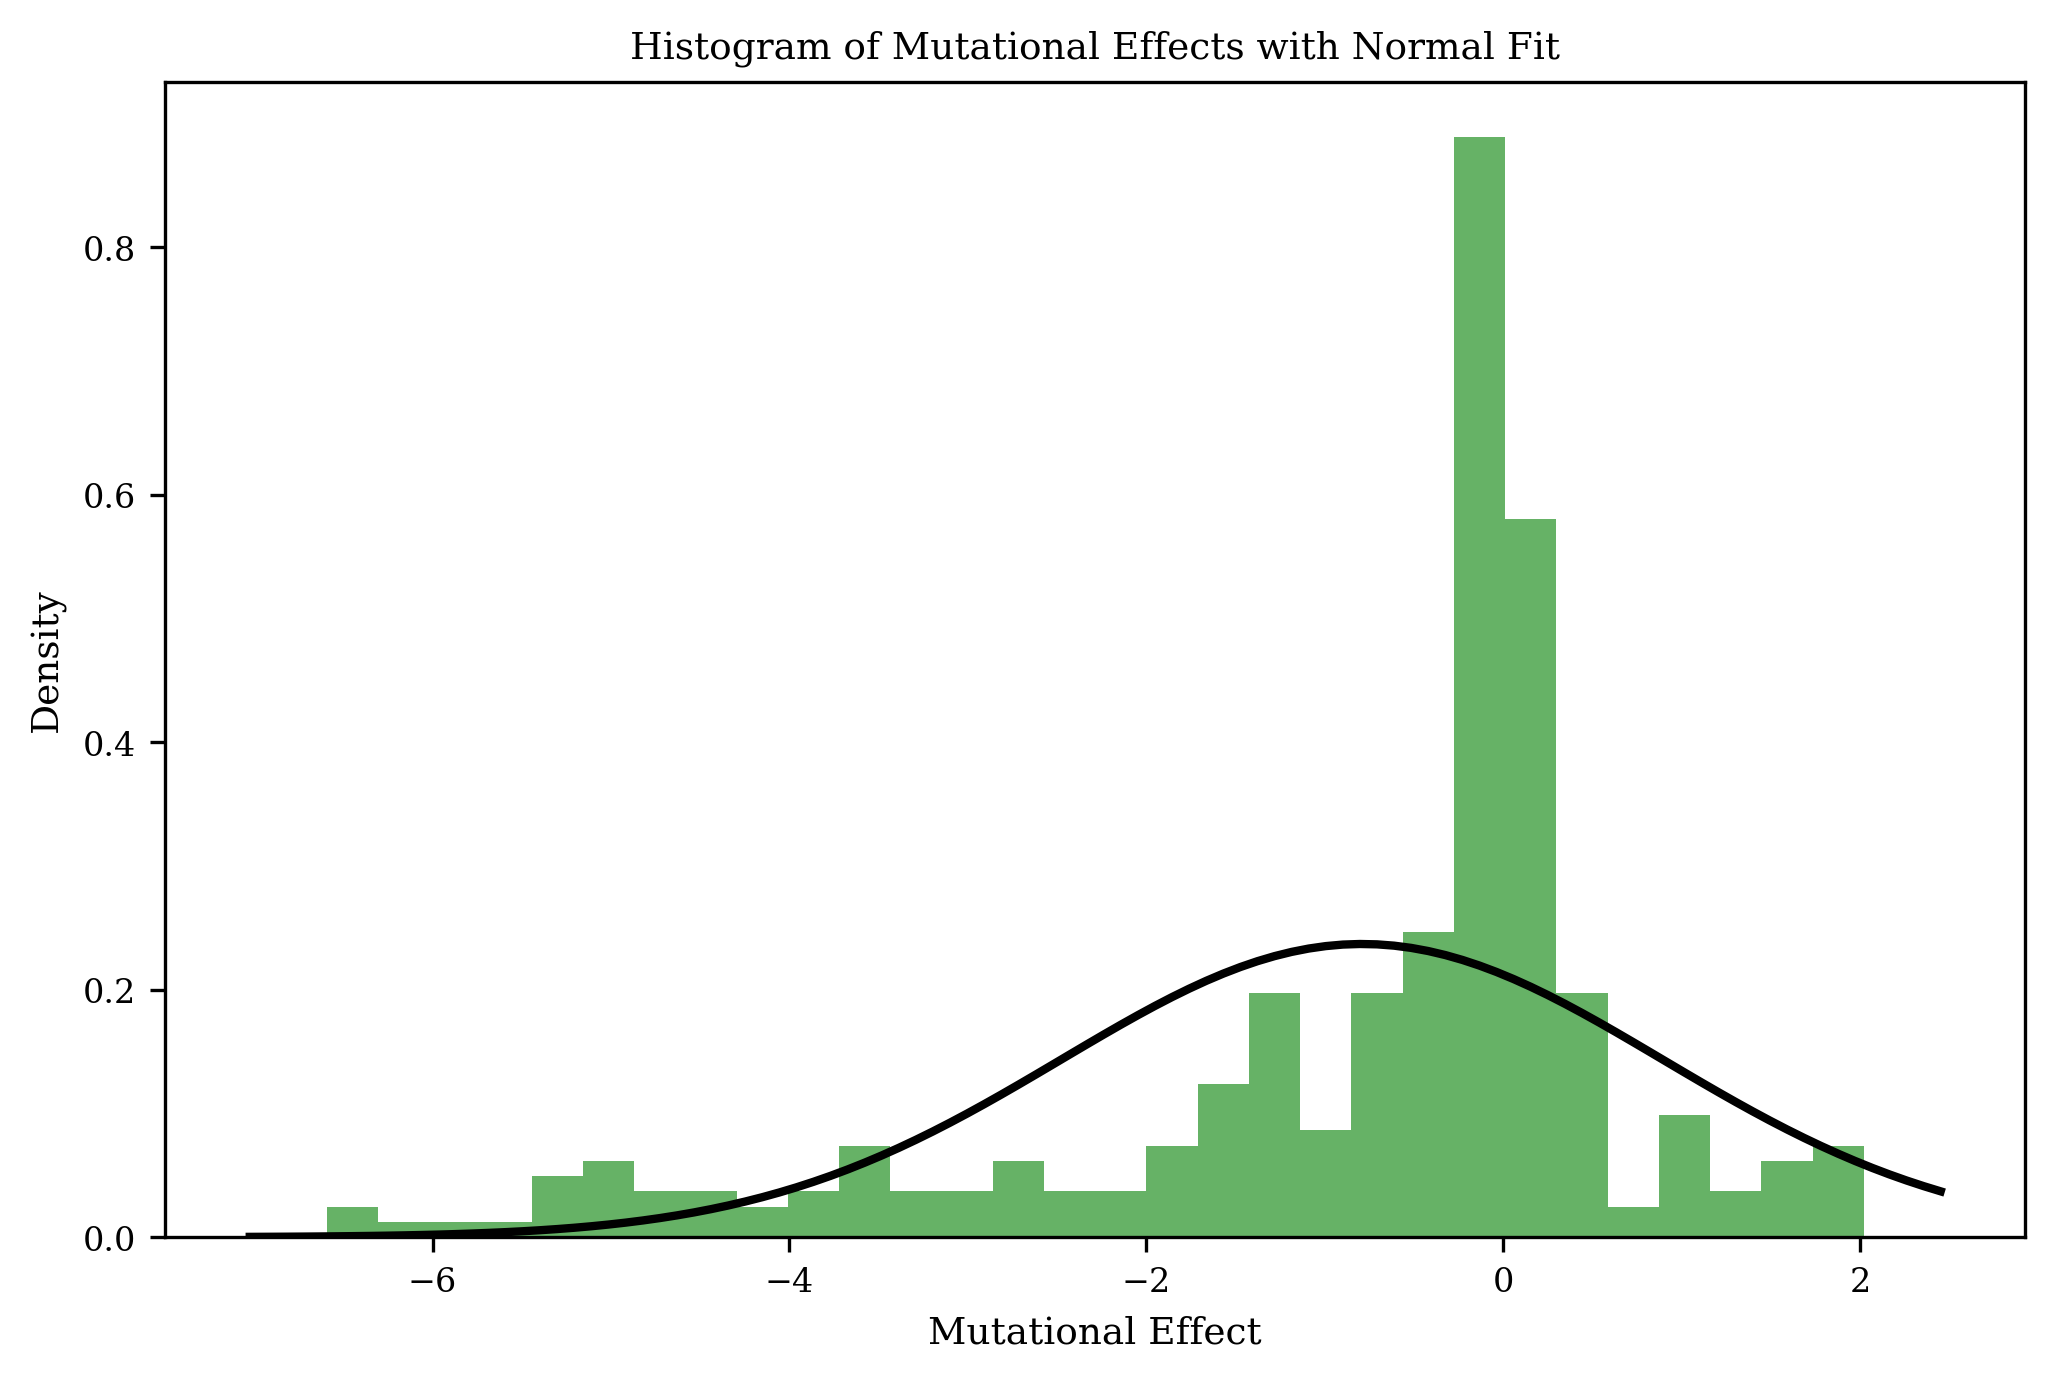

In [59]:
# 1. Create the dictionary with absolute positions from the dataframe
df['delta_bind_scaled'] = df['delta_bind_CGG'] * np.log(10)

mut_effects_dict_abs = df.groupby('position')['delta_bind_scaled'].apply(lambda x: x.to_numpy()).to_dict()

# 2. Re-key the dictionary to use relative indices (0 to N_h - 1)
# 'positions' is your array of absolute positions: positions = stats["position"].to_numpy()
mut_effects_dict = {
    i: mut_effects_dict_abs[pos] 
    for i, pos in enumerate(positions)
}
mut_effects_dict

#print mean and std of all effects across all positions
all_effects = np.concatenate(list(mut_effects_dict.values()))
print("Overall mean of mutational effects:", all_effects.mean())
print("Overall std of mutational effects:", all_effects.std())

#plot histogram and normal fit
plt.figure(figsize=(8, 5))
plt.hist(all_effects, bins=30, density=True, alpha=0.6, color='g')
from scipy.stats import norm
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, all_effects.mean(), all_effects.std())
plt.plot(x, p, 'k', linewidth=2)
plt.title("Histogram of Mutational Effects with Normal Fit")
plt.xlabel("Mutational Effect")
plt.ylabel("Density")
plt.show()

### Mixture of gaussians analysis

In [24]:
import numpy as np

# Calculate the mean of the mixture
mu_mix = np.mean(mu_arr)

# Calculate the variance of the mixture (Law of Total Variance)
# Term 1: Average of the variances
# Term 2: Variance of the means
var_mix = np.mean(sigma_arr**2) + np.mean((mu_arr - mu_mix)**2)

# Calculate the standard deviation
std_mix = np.sqrt(var_mix)

print(f"Mixture Mean: {mu_mix}")
print(f"Mixture Standard Deviation: {std_mix}")

Mixture Mean: -0.7968246924246601
Mixture Standard Deviation: 1.7581567263349918


# Keep normal distrib


In [25]:
positions

array([ 25,  26,  27,  28,  29,  30,  31,  32,  49,  50,  51,  52,  53,
        54,  55,  56,  95,  96,  97,  98,  99, 100, 153, 154, 155, 156,
       157, 158, 176, 177, 178, 215, 216, 217, 218, 219, 220, 221, 222,
       223])

In [26]:
print(df.annotation.unique())
# Keep only unique (position, annotation) pairs
pos_annotation_dict = (
    df.drop_duplicates(subset=["position", "annotation"])
      .set_index("position")["annotation"]
      .to_dict()
)

print(pos_annotation_dict)
cdr_positions = (
    df[df["annotation"].str.contains("CDR", na=False)]
    .drop_duplicates(subset=["position"])
    [["position"]]
    .to_records(index=False)
    .tolist()
)
cdr_positions=[pos[0] for pos in cdr_positions]
print(cdr_positions)#absolute position
#i need index of cdr_positions inside position array
cdr_positions_relative = [np.where(positions == p)[0][0] for p in cdr_positions]

print(cdr_positions_relative)

['CDRH1' 'CDRH2' 'CDRH3' 'CDRL1' 'CDRL2' 'CDRL3']
{25: 'CDRH1', 26: 'CDRH1', 27: 'CDRH1', 28: 'CDRH1', 29: 'CDRH1', 30: 'CDRH1', 31: 'CDRH1', 32: 'CDRH1', 49: 'CDRH2', 50: 'CDRH2', 51: 'CDRH2', 52: 'CDRH2', 53: 'CDRH2', 54: 'CDRH2', 55: 'CDRH2', 56: 'CDRH2', 95: 'CDRH3', 96: 'CDRH3', 97: 'CDRH3', 98: 'CDRH3', 99: 'CDRH3', 100: 'CDRH3', 153: 'CDRL1', 154: 'CDRL1', 155: 'CDRL1', 156: 'CDRL1', 157: 'CDRL1', 158: 'CDRL1', 176: 'CDRL2', 177: 'CDRL2', 178: 'CDRL2', 215: 'CDRL3', 216: 'CDRL3', 217: 'CDRL3', 218: 'CDRL3', 219: 'CDRL3', 220: 'CDRL3', 221: 'CDRL3', 222: 'CDRL3', 223: 'CDRL3'}
[25, 26, 27, 28, 29, 30, 31, 32, 49, 50, 51, 52, 53, 54, 55, 56, 95, 96, 97, 98, 99, 100, 153, 154, 155, 156, 157, 158, 176, 177, 178, 215, 216, 217, 218, 219, 220, 221, 222, 223]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]


In [27]:
cdr_positions_relative

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39]

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Load and Process Experimental Data (from original code, unchanged) ---
# NOTE: Assume 'simulate_gc_history', T, S_mat, N_i, N_max, C_schedule, mu_arr,
# sigma_arr, and cdr_positions_relative are defined elsewhere in the context.
S_mat = np.array([[1] for pos in range (len(positions))])

N_h   = S_mat.shape[0]
print('Nh', N_h)
# Antigen concentration (constant here)
c=170
def C_schedule(r):
    return np.array([c])

Nh 40


In [48]:
len(mut_effects_dict.keys())

40

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Define Simulation Parameters (PLACEHOLDERS: Replace with your actual context variables) ---
# NOTE: The following variables must be defined in your environment:
# T, S_mat, N_i, N_max, C_schedule, mu_arr, sigma_arr, cdr_positions_relative, 
# simulate_gc_history, positions 

N_SEEDS = 10 




# --- 3. Run Multiple Simulations and Collect Results ---

# List to store mean total affinity (sum(h_i)) for each simulation round (Shape: (10, T+1))
all_sim_mean_sum_hi = [] 
# List to store mean h_i per position for each simulation (Shape: (10, T+1, N_h))
all_sim_mean_hi_per_time = [] 
# Initialize storage for all seeds
all_sim_mean_sum_hi = []
all_sim_mean_hi_per_time = []

for seed in range(N_SEEDS):
    # Run the simulation 
    history = simulate_gc_with_ancestry(
    rounds            = T,
    S_mat             = S_mat,
    N_init            = N_i,
    N_max             = N_max,
    C_schedule        = C_schedule,
    mut_effects_dict  = mut_effects_dict, # Passing the dictionary
    mutable_positions = cdr_positions_relative,
    seed              = seed + 1
)

    # Extract N_h from the 'pop' array of the first frame
    N_h = history[0]['pop'].shape[1]
    
    # Trackers for the current simulation
    current_sim_mean_sum_hi = []
    mean_hi_per_time_single_sim = np.zeros((len(history), N_h))

    for t, frame in enumerate(history):
        pop = frame['pop'] # Extract the population array from the dictionary
        
        if pop.size == 0:
            # Handle empty population for both metrics
            current_sim_mean_sum_hi.append(np.nan)
            mean_hi_per_time_single_sim[t, :] = np.nan
        else:
            # === KEY MODIFICATION ===
            # Fill NaNs with 0.0 to treat unmutated positions as 0 affinity contribution
            # This ensures we calculate the mean over the *entire* population
            pop_filled = np.nan_to_num(pop, nan=0.0)

            # 1. Total Affinity (sum(h_i)) tracking: Mean of the sum over population
            sum_hi_per_cell = pop_filled.sum(axis=1) 
            current_sim_mean_sum_hi.append(sum_hi_per_cell.mean())
            
            # 2. Individual h_i tracking: Mean h_i per position over population
            mean_hi_per_time_single_sim[t, :] = pop_filled.mean(axis=0)

    all_sim_mean_sum_hi.append(current_sim_mean_sum_hi)
    all_sim_mean_hi_per_time.append(mean_hi_per_time_single_sim)
    
    print(f"Simulation with seed={seed + 1} completed.")

# --- 4. Aggregate and Plot Total Affinity (sum(h_i)) ---

# Convert list of lists to a NumPy array for aggregation
sim_sum_hi_array = np.array(all_sim_mean_sum_hi) 

# Calculate the mean and standard deviation across the N_SEEDS simulations for plotting
sim_mean_agg = np.nanmean(sim_sum_hi_array, axis=0) 
sim_std_agg = np.nanstd(sim_sum_hi_array, axis=0) 

#print affinities at last step
print("\nTotal Affinity Tracking (sum(h_i)) at final step:")
print(sim_sum_hi_array[:, -1])  # Print the final step values for all simulations


times = np.arange(len(history))

print("\nTotal Affinity Tracking (sum(h_i))")
print(f"Aggregated Mean: {sim_mean_agg}")
print(f"Aggregated STD: {sim_std_agg}")

Simulation with seed=1 completed.
Simulation with seed=2 completed.
Simulation with seed=3 completed.
Simulation with seed=4 completed.
Simulation with seed=5 completed.
Simulation with seed=6 completed.
Simulation with seed=7 completed.
Simulation with seed=8 completed.
Simulation with seed=9 completed.
Simulation with seed=10 completed.

Total Affinity Tracking (sum(h_i)) at final step:
[4.15398322 3.57130495 3.24669436 4.13692079 3.0692088  3.4845593
 3.62539898 3.82642104 3.5294076  3.26787119]

Total Affinity Tracking (sum(h_i))
Aggregated Mean: [-2.80759706e-06  3.12649570e-04  1.35916471e-03  5.08226386e-03
  9.82763337e-03  1.87427715e-02  2.66980868e-02  3.57276698e-02
  4.75515368e-02  6.07651528e-02  7.59058796e-02  9.27933058e-02
  1.14440227e-01  1.41479823e-01  1.68527238e-01  1.98047535e-01
  2.33874087e-01  2.79315057e-01  3.12791658e-01  3.65254400e-01
  4.19298007e-01  4.65608048e-01  5.25542157e-01  5.86316616e-01
  6.55858881e-01  7.33801822e-01  8.02378614e-01  8.7

<>:25: SyntaxWarning: invalid escape sequence '\p'
<>:25: SyntaxWarning: invalid escape sequence '\p'
C:\Users\maria\AppData\Local\Temp\ipykernel_9988\2650847876.py:25: SyntaxWarning: invalid escape sequence '\p'
  label="$\pm$1 STD (across 10 seeds)"


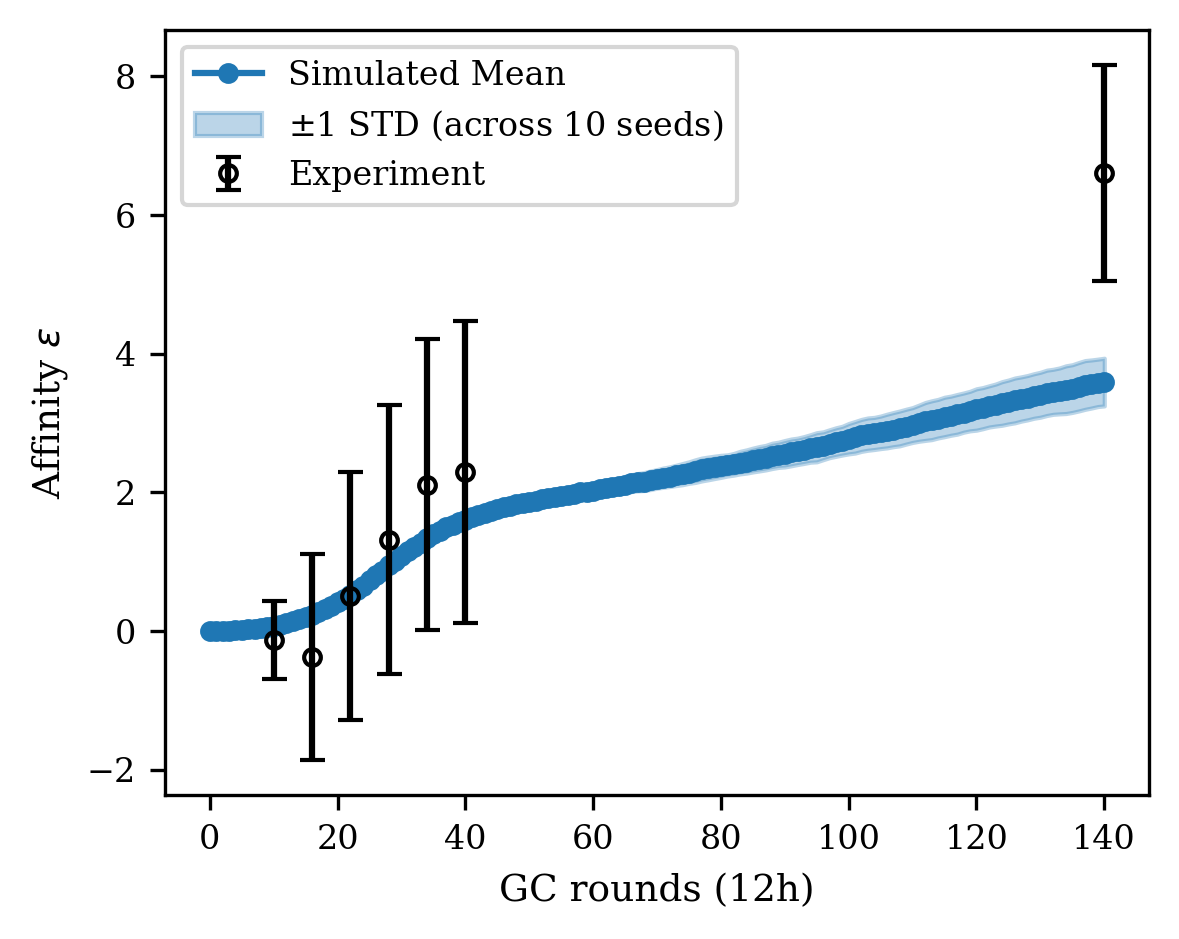

In [50]:
df_mat = (pd.read_csv("../data_mat/data.csv", keep_default_na=False)
         [["time (days)", "delta_bind_CGG"]]
         .rename(columns={"time (days)": "t", "delta_bind_CGG": "x"}))

df_mat["t"] = df_mat["t"] * 2.0         # days -> 12h
df_mat["x"] = df_mat["x"] * np.log(10.0)  # log scale

times_exp = np.sort(df_mat.t.unique())
exp_mean = (df_mat.groupby("t")["x"]
                .mean()
                .reindex(times_exp)
                .values)
exp_std = (df_mat.groupby("t")["x"].std()
               .reindex(times_exp)
               .fillna(0.0)
               .values)
plt.figure(figsize=(4, 3.2), dpi=300)
plt.plot(times, sim_mean_agg, marker='o', color='C0', label="Simulated Mean")
plt.fill_between(
    times,
    sim_mean_agg - sim_std_agg,
    sim_mean_agg + sim_std_agg,
    color='C0',
    alpha=0.3,
    label="$\pm$1 STD (across 10 seeds)"
)

# Plot the experimental data
plt.errorbar(times_exp, exp_mean, yerr=exp_std,
             fmt='o', mfc='none', ecolor='k', color='k',
             capsize=3, label='Experiment')

plt.xlabel("GC rounds (12h)")
plt.ylabel(r"Affinity $\epsilon$")
# plt.title("Model affinity maturation (10 Replicates)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


In [51]:
# --- 5. Aggregate and Save Individual h_i (All Positions) ---

# Convert the list of (T+1, N_h) arrays into a single NumPy array
# Shape: (N_SEEDS, N_times, N_h)
sim_hi_array = np.array(all_sim_mean_hi_per_time) 

# Calculate the final mean h_i averaged over the 10 simulation seeds (axis=0)
# Shape: (N_times, N_h)
mean_hi_per_time_avg = np.nanmean(sim_hi_array, axis=0)

# Define times of interest (in 12h rounds)
times_of_interest = np.array([5, 8, 11, 14, 17, 20, 70]) * 2

# Get total number of positions
N_h = mean_hi_per_time_avg.shape[1]

# Build a DataFrame using the *averaged* mean h_i values for ALL positions
records = []

# Iterate through ALL positions (no filtering)
for i in range(N_h):
    position_label = positions[i] # Uses 'positions' list from your environment
    
    for t in times_of_interest:
        # Ensure we don't access out-of-bounds time indices
        if t < len(mean_hi_per_time_avg):
            records.append({
                "position": position_label,
                "time": t,
                "mean_hi": mean_hi_per_time_avg[t, i]
            })

df_out = pd.DataFrame(records)

# Save to CSV
df_out.to_csv("mean_hi_stochastic_empirical.csv", index=False)
print(f"\nSaved mean h_i values (averaged over {N_SEEDS} simulations) for {len(records)} entries.csv")


Saved mean h_i values (averaged over 10 simulations) for 280 entries.csv


In [52]:
import numpy as np

# ---------------------- Lineage Reconstruction ----------------------
def trace_lineages(history, target_indices_at_end):
    """
    Reconstructs affinity trajectories for specific cells found in the last step.
    Affinity is defined as the sum of h_i across all positions for a given cell.
    
    Parameters
    ----------
    history : list of dicts
        The output from simulate_gc_with_ancestry.
    target_indices_at_end : array-like
        Indices in the *last* history frame of the cells you want to trace.
        
    Returns
    -------
    trajectories : list of numpy arrays
        A list where each element is a 1D array of shape (T+1,)
        representing the total affinity path of a single lineage.
    """
    if not history:
        return []

    # Get the last frame
    final_step = len(history) - 1
    last_frame = history[final_step]
    
    # These are the IDs we want to trace back
    current_ids_to_trace = last_frame['ids'][target_indices_at_end]
    
    # Map: Final_Unique_ID -> Current_Ancestor_ID
    active_traces = {uid: uid for uid in current_ids_to_trace}
    
    # Storage: Final_Unique_ID -> List of total affinities
    results = {uid: [] for uid in current_ids_to_trace}
    
    for t in range(final_step, -1, -1):
        frame = history[t]
        
        # Create lookup for this frame: ID -> (Index, Parent_ID, Vector)
        frame_lookup = {uid: (i, pid, vec) 
                       for i, (uid, pid, vec) 
                       in enumerate(zip(frame['ids'], frame['parent_ids'], frame['pop']))}
        
        for final_uid, ancestor_id in list(active_traces.items()):
            if ancestor_id in frame_lookup:
                _, parent_id, vector = frame_lookup[ancestor_id]
                
                # --- MODIFICATION: Calculate total affinity (sum of h_i) ---
                total_affinity = np.sum(np.nan_to_num(vector, nan=0.0))
                results[final_uid].append(total_affinity)
                
                # Step back: looking for parent in previous frame
                if parent_id != -1:
                    active_traces[final_uid] = parent_id
                else:
                    # Reached root
                    del active_traces[final_uid]
            else:
                # Should not happen in an unbroken chain
                del active_traces[final_uid]
                
    # Reverse lists to get time 0 -> T
    trajectories = []
    for uid in current_ids_to_trace:
        traj = np.array(results[uid][::-1])
        trajectories.append(traj)
        
    return trajectories

# ---------------------- Run & Plot Logic ----------------------

# Run Simulation
print("Simulating...")
history = simulate_gc_with_ancestry(
        rounds            = T,
        S_mat             = S_mat,
        N_init            = N_i,
        N_max             = N_max,
        C_schedule        = C_schedule,
        mut_effects_dict  = mut_effects_dict, # Passing the dictionary
        mutable_positions = cdr_positions_relative,
        seed              = 42
    )

# 1. Identify Target Cells in the Final Population
last_frame = history[-1]
final_pop = last_frame['pop']

# --- MODIFICATION: Calculate total affinity using sum(h_i) ---
final_affinities = np.sum(np.nan_to_num(final_pop, nan=0.0), axis=1)
print('mean', final_affinities.mean())


Simulating...
mean 3.613890135268044


Simulation ended with 2500 cells.
Found 0 cells with 9.5 <= affinity < 10.5.


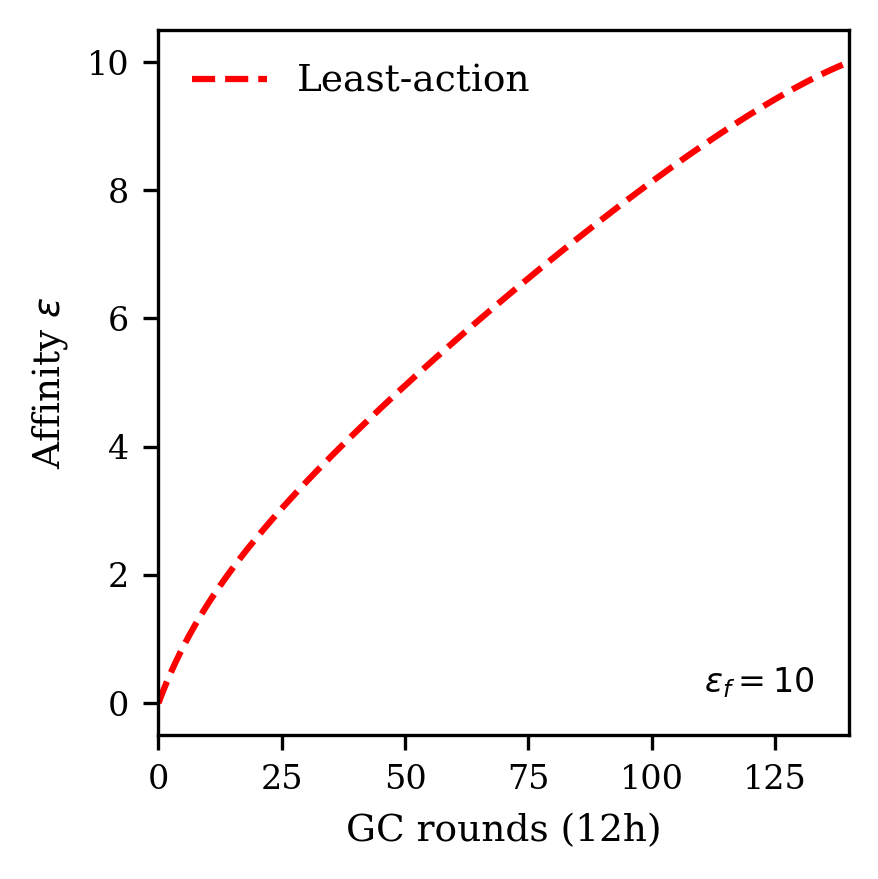

In [53]:
# Filter: Find indices where 5.5 <= affinity < 6.5
target=10
target_indices = np.where((final_affinities >= target - 0.5) & (final_affinities < target + 0.5))[0]

print(f"Simulation ended with {len(final_pop)} cells.")
print(f"Found {len(target_indices)} cells with {target - 0.5} <= affinity < {target + 0.5}.")

# 2. Get Trajectories
trajectories = trace_lineages(history, target_indices)
plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.markersize": 4,
    "figure.figsize": (3., 3.),  # ≈8.6 cm × 6.6 cm
    "figure.dpi": 300,
    "font.family": "serif",        # Often preferred in papers
})

# --- Load trajectory from CSV ----------------------------------------
try:
    # Try loading the file if it exists
    h_sol = np.loadtxt("../multi Ag/trajectory_h_140_"+str(target)+".csv")
    T = T_steps
    n_points = len(h_sol)
    t_sol = np.linspace(0, T, n_points)
except OSError:
    # Fallback if file not found (allows script to run without file)
    h_sol = None
    t_sol = None
    T = T_steps

# --- Prepare B-cell lineage trajectories ------------------------------
h1_by_round = defaultdict(list)
fig, ax = plt.subplots()
first = True

# Map existing 'trajectories' list to the logic structure requested
for traj in trajectories:
    h1 = traj.flatten() # 1D antigen assumption
    rounds = np.arange(len(h1))

    for t, h in zip(rounds, h1):
        h1_by_round[t].append(h)
    
    if first:
        ax.plot(rounds, h1, lw=0.5, color='lightgrey', label='Stochastic')
        first = False
    else:
        ax.plot(rounds, h1, lw=0.5, color='lightgrey')

# --- Plot mean trajectory in blue -------------------------------------
if h1_by_round:
    common_rounds = sorted(h1_by_round.keys())
    mean_h1 = [np.mean(h1_by_round[t]) for t in common_rounds]
    ax.plot(common_rounds, mean_h1, lw=1.5, color='red', label='Mean stochastic')

# --- Plot least-action trajectory in red ------------------------------
if h_sol is not None:
    ax.plot(t_sol, h_sol, lw=1.5, color='red', label='Least-action', linestyle='--')

# --- Final formatting -------------------------------------------------
t_max = T_steps
ax.set_xlim(0, t_max)
ax.set_xlabel("GC rounds (12h)")
ax.set_ylabel(r"Affinity $\epsilon$")
ax.legend(frameon=False, loc="upper left")
# ax.set_title(r"Lineages reaching affinity $\epsilon\sim6$")
fig.tight_layout()
#put in text epsilon_f=10
ax.text(0.95, 0.05, r"$\epsilon_f = 10$", transform=ax.transAxes, ha='right', va='bottom', fontsize=8)
plt.show()


Target 3: Found 860 cells.
Target 7: Found 9 cells.
Target 10: Found 0 cells.


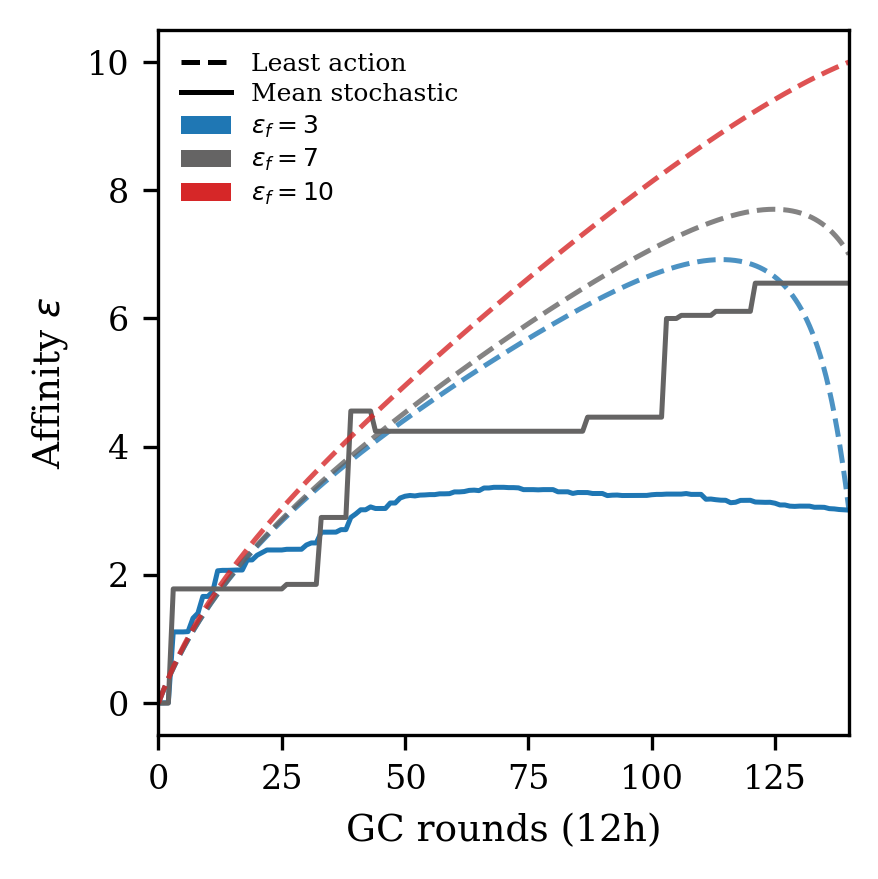

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# --- 1. Publication Style Preferences ---
plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.markersize": 4,
    "figure.figsize": (3., 3.),
    "figure.dpi": 300,
    "font.family": "serif",
})

# --- 2. Configuration ---
targets = [3,7,10]

# Generate colors from Red to Blue using the 'coolwarm' colormap
# 0.9 gives deep red, 0.1 gives deep blue. We linspace between them.
colors = [plt.cm.coolwarm(x) for x in np.linspace(0.9, 0.1, len(targets))]
colors = [ '#1f77b4',  "#656464",'#d62728']
fig, ax = plt.subplots()

for i, (t_val, color) in enumerate(zip(targets, colors)):
    # --- Identify Stochastic Indices ---
    # Note: final_energies must be defined in your previous context
    target_indices = np.where((final_affinities >= t_val - 0.5) & (final_affinities < t_val + 0.5))[0]
    print(f"Target {t_val}: Found {len(target_indices)} cells.")

    # --- Plot Least-action (Theory) ---
    try:
        # Note: T_steps must be defined in your previous context
        h_sol = np.loadtxt(f"../multi Ag/trajectory_h_140_{t_val}.csv", delimiter=",")
        n_points = len(h_sol)
        t_sol = np.linspace(0, T_steps, n_points)
        
        # Plot
        ax.plot(t_sol, h_sol, lw=1.2, linestyle='--', color=color, alpha=0.8)
    except OSError:
        print(f"Warning: Could not load trajectory file for target {t_val}")

    # --- Plot Mean Stochastic (Simulation) ---
    if len(target_indices) > 0:
        # Note: trace_lineages and history must be defined in your previous context
        trajectories = trace_lineages(history, target_indices)
        
        h1_by_round = defaultdict(list)
        for traj in trajectories:
            h1 = traj.flatten()
            rounds = np.arange(len(h1))
            for r, h in zip(rounds, h1):
                h1_by_round[r].append(h)
        
        if h1_by_round:
            common_rounds = sorted(h1_by_round.keys())
            mean_h1 = [np.mean(h1_by_round[r]) for r in common_rounds]
            
            # Plot
            ax.plot(common_rounds, mean_h1, lw=1.2, linestyle='-', color=color)

# --- 3. Custom Legend Construction ---
legend_elements = [
    # Line styles (Black)
    Line2D([0], [0], color='black', lw=1.2, linestyle='--', label='Least action'),
    Line2D([0], [0], color='black', lw=1.2, linestyle='-', label='Mean stochastic'),
    
    # Target Colors (Rectangles) - Dynamic reference to the colors list
    Patch(facecolor=colors[0], edgecolor='none', label=rf'$\epsilon_f={targets[0]}$'),
    Patch(facecolor=colors[1], edgecolor='none', label=rf'$\epsilon_f={targets[1]}$'),
    Patch(facecolor=colors[2], edgecolor='none', label=rf'$\epsilon_f={targets[2]}$'),
]

# --- 4. Final Formatting ---
ax.set_xlim(0, T_steps)
ax.set_xlabel("GC rounds (12h)")
ax.set_ylabel(r"Affinity $\epsilon$")

# Add the custom legend
ax.legend(handles=legend_elements, frameon=False, loc="upper left", fontsize=6, labelspacing=0.3)
# ax.set_title(r"Mean vs Theory Trajectories")

fig.tight_layout()
plt.show()


# Histogram

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
for seed in [1]:
    # ---------------------- Final Affinity Histogram ----------------------
    c_array = [50,100]
    for c in c_array:
        # IMPORTANT: Commented out the local C_schedule override so this 
        # snippet uses the exact same global C_schedule as Snippet 1.
        # def C_schedule(): return np.array([c])
        
        # Run Simulation
        print(f"Simulating for c={c}...")
        history = simulate_gc_with_ancestry(
            rounds=T,                # Corrected: Matches Snippet 1 exactly (was T_steps)
            S_mat=S_mat,
            N_init=N_i,
            N_max=N_max,
            C_schedule=C_schedule,   # Now uses the identical global C_schedule
            mu_M=mu_arr,             
            sigma_M=sigma_arr,       
            mutable_positions=cdr_positions_relative, 
            seed=seed,                   # Corrected: Matches the first seed run in Snippet 1
            sigma_init=sigma_i,             # Ensure same initial conditions as Snippet 1
            mu_init=mu_i

        )
        
        # 1. Extract the final state from history
        final_frame = history[-1]
        final_pop = final_frame['pop']

        # 2. Calculate total affinities (sum of h_i) for the final population
        final_affinities = np.sum(np.nan_to_num(final_pop, nan=0.0), axis=1)
        
        print(f"Final population size for c={c}: {len(final_affinities)}")
        print(final_affinities.mean())

        

        # Load the csv of results from fokker planck
        fp_filename = f'../multi Ag/rho_epsilon_last_step_c={c}.csv'
        df_fp = pd.read_csv(fp_filename)
        eps_fp = df_fp['epsilon']
        rho_fp = df_fp['rho_epsilon']

        # 3. Create the Histogram Plot
        plt.figure(figsize=(3, 2.6), dpi=300)  # Maintaining your PRL-style sizing

        # Plot histogram of stochastic simulation and CAPTURE the bins
        counts, bins, patches = plt.hist(
            final_affinities, bins=30, color='skyblue', edgecolor='navy', 
            alpha=0.7, label='Stochastic'
        )

        # Calculate the bin width of the stochastic histogram
        bin_width = bins[1] - bins[0]
        
        # Calculate the grid spacing of the Fokker-Planck continuous data
        deps_fp = eps_fp.iloc[1] - eps_fp.iloc[0]
        
        # Scale rho_fp smoothly to match the histogram 'Count' scale.
        scaled_rho_fp = rho_fp * (bin_width / deps_fp)

        # Plot Fokker Planck smoothly using its native resolution
        plt.plot(eps_fp, scaled_rho_fp, color='darkorange', label='Fokker-Planck', linestyle='--')

        # 4. Formatting
        plt.xlabel(r"Affinity $\epsilon$")
        plt.ylabel("Count")

        plt.legend(frameon=False, fontsize='small')
        plt.tight_layout()
        plt.ylim(0, 800)  # Adjust y-limit for better visualization

        plt.show()


Simulating for c=50...


TypeError: simulate_gc_with_ancestry() got an unexpected keyword argument 'mu_M'

Simulating for c=50...
Final population size for c=50: 2500
11.128930272705732
rho_fp [1.15999942e-50 4.14463669e-50 1.76962447e-49 7.57016821e-49
 3.21223078e-48 1.35138543e-47 5.63683309e-47 2.33131002e-46
 9.56096224e-46 3.88838453e-45 1.56831521e-44 6.27372480e-44
 2.48930175e-43 9.79764933e-43 3.82552261e-42 1.48189057e-41
 5.69546654e-41 2.17200459e-40 8.21939322e-40 3.08669943e-39
 1.15040545e-38 4.25533990e-38 1.56231002e-37 5.69338779e-37
 2.05950962e-36 7.39542678e-36 2.63623273e-35 9.32906139e-35
 3.27745204e-34 1.14310817e-33 3.95819546e-33 1.36072510e-32
 4.64418136e-32 1.57367131e-31 5.29399582e-31 1.76813219e-30
 5.86276653e-30 1.92992632e-29 6.30697462e-29 2.04613426e-28
 6.58974932e-28 2.10675017e-27 6.68579257e-27 2.10607363e-26
 6.58504666e-26 2.04357939e-25 6.29438193e-25 1.92408421e-24
 5.83692219e-24 1.75715871e-23 5.24907477e-23 1.55587847e-22
 4.57578103e-22 1.33513762e-21 3.86484194e-21 1.10982656e-20
 3.16131695e-20 8.93185170e-20 2.50291217e-19 6.95584008e-19

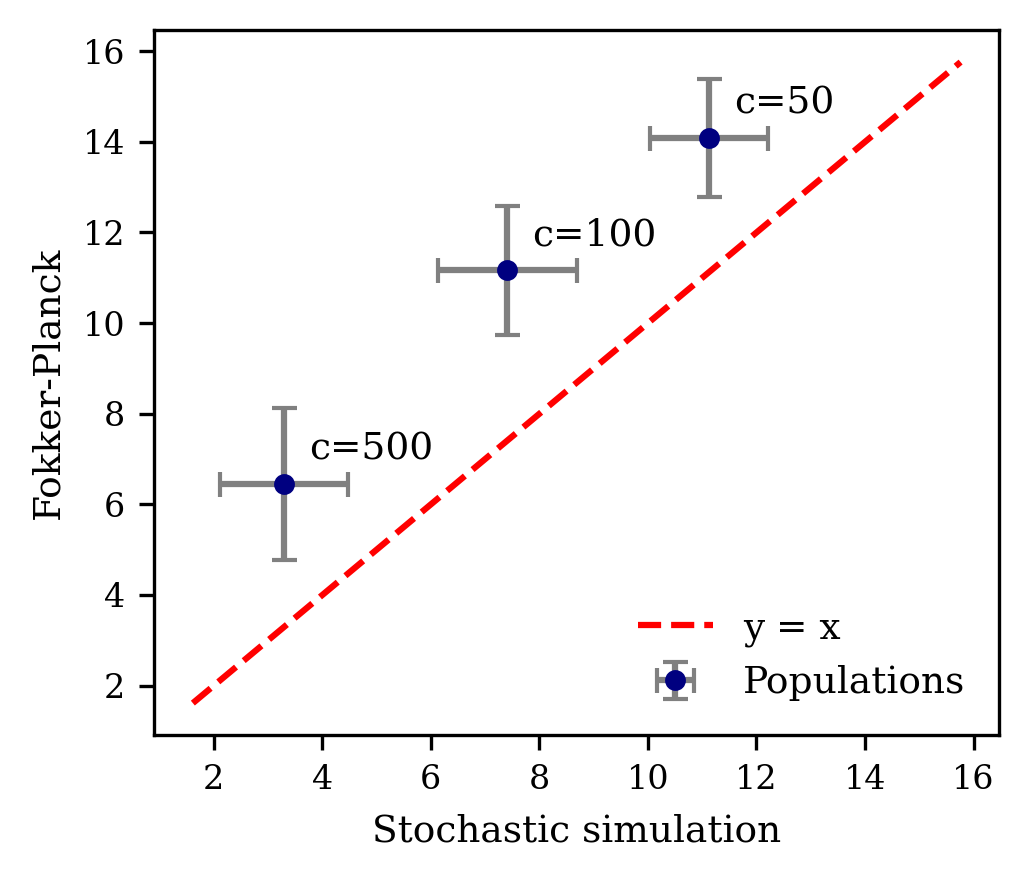

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------- Mean Affinity vs FP Comparison ----------------------
c_array = [50, 100, 500]

stoch_means, stoch_stds = [], []
fp_means, fp_stds = [], []
valid_c = []
dead_c_info = []

for c in c_array:
    def C_schedule(r): return np.array([c])
    
    # Run Simulation
    print(f"Simulating for c={c}...")
    history = simulate_gc_with_ancestry(
        rounds=T,                # Corrected: Matches Snippet 1 exactly (was T_steps)
        S_mat=S_mat,
        N_init=N_i,
        N_max=N_max,
        C_schedule=C_schedule,   # Now uses the identical global C_schedule
        mu_M=mu_arr,             
        sigma_M=sigma_arr,       
        mutable_positions=cdr_positions_relative, 
        seed=1                   # Corrected: Matches the first seed run in Snippet 1
    )
    
    # 1. Extract the final state from history
    final_frame = history[-1]
    final_pop = final_frame['pop']

    # 2. Calculate total affinities (sum of h_i) for the final population
    final_affinities = np.sum(np.nan_to_num(final_pop, nan=0.0), axis=1)
    
    print(f"Final population size for c={c}: {len(final_affinities)}")
    print(final_affinities.mean())


    # Load the csv of results from fokker planck
    fp_filename = f'../multi Ag/rho_epsilon_last_step_c={c}.csv'
    try:
        df_fp = pd.read_csv(fp_filename)
        eps_fp = df_fp['epsilon'].values
        rho_fp = df_fp['rho_epsilon'].values
    except FileNotFoundError:
        eps_fp, rho_fp = np.array([]), np.array([])

    # 3. Check for dead populations
    stoch_dead = len(final_affinities) == 0
    fp_dead = len(rho_fp) == 0 or not np.sum(rho_fp) > 1 
    print('rho_fp', rho_fp)

    if stoch_dead or fp_dead:
        if stoch_dead and fp_dead:
            status = "Dead"
        elif stoch_dead:
            status = "Stoch Dead"
        else:
            status = "FP Dead"
        
        dead_c_info.append(f"c={c}: {status}")
        continue  # Skip plotting points for dead populations

    # 4. Calculate Stochastic Moments
    stoch_means.append(np.mean(final_affinities))
    stoch_stds.append(np.std(final_affinities))

    # 5. Calculate Fokker-Planck Moments
    total_mass = np.sum(rho_fp)
    mean_fp = np.sum(eps_fp * rho_fp) / total_mass
    
    # Variance = E[X^2] - (E[X])^2
    var_fp = np.sum((eps_fp**2) * rho_fp) / total_mass - (mean_fp**2)
    # Ensure no negative variance due to floating point inaccuracies
    std_fp = np.sqrt(max(0, var_fp)) 

    fp_means.append(mean_fp)
    fp_stds.append(std_fp)
    valid_c.append(c)


# ---------------------- Plotting ----------------------
plt.figure(figsize=(3.5, 3), dpi=300)

if valid_c:
    # Scatter plot with double error bars
    plt.errorbar(
        stoch_means, fp_means, 
        xerr=stoch_stds, yerr=fp_stds, 
        fmt='o', color='navy', ecolor='gray', capsize=3, label='Populations'
    )
    
    # Annotate each point with its concentration
    for i, c in enumerate(valid_c):
        plt.annotate(
            f"c={c}", 
            (stoch_means[i], fp_means[i]), 
            textcoords="offset points", 
            xytext=(6, 6), 
            ha='left', 
            fontsize=9
        )

    # Add reference line y = x to show perfect agreement
    min_val = min(min(stoch_means), min(fp_means)) - max(max(stoch_stds), max(fp_stds))
    max_val = max(max(stoch_means), max(fp_means)) + max(max(stoch_stds), max(fp_stds))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1.5, label='y = x')

# If any populations died, list them in a text box on the graph
if dead_c_info:
    text_str = dead_c_info[0]
    plt.gca().text(
        0.75, 0.95, text_str, 
        transform=plt.gca().transAxes,
        fontsize=8, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='mistyrose', edgecolor='red', alpha=0.7)
    )

plt.xlabel("Stochastic simulation")
plt.ylabel("Fokker-Planck")
# plt.title("Affinity Comparison (Stochastic vs FP)")

plt.legend(frameon=False, loc='lower right')
# plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------- Mean Affinity vs FP Comparison ----------------------
c_array = [50,100, 500]
N_SEEDS = 10

stoch_means, stoch_stds = [], []
fp_means = []
valid_c = []
dead_c_info = []

for c in c_array:
    def C_schedule(r): return np.array([c])
    
    print(f"Simulating for c={c} across {N_SEEDS} seeds...")
    
    seed_mean_affinities = []
    
    # Run Simulation for 10 seeds
    for seed in range(N_SEEDS):
        history = simulate_gc_with_ancestry(
            rounds=T,                
            S_mat=S_mat,
            N_init=N_i,
            N_max=N_max,
            C_schedule=C_schedule,   
            mu_M=mu_arr,             
            sigma_M=sigma_arr,       
            mutable_positions=cdr_positions_relative, 
            seed=seed+1              
        )
        
        # Extract the final state from history
        final_frame = history[-1]
        final_pop = final_frame['pop']

        # If population is not dead, calculate and store its mean affinity
        if len(final_pop) > 0:
            final_affinities = np.sum(np.nan_to_num(final_pop, nan=0.0), axis=1)
            seed_mean_affinities.append(np.mean(final_affinities))
            print(f"Seed {seed+1}: Mean Affinity = {seed_mean_affinities[-1]:.4f}")
    # Load the csv of results from fokker planck
    fp_filename = f'../multi Ag/rho_epsilon_last_step_c={c}.csv'
    try:
        df_fp = pd.read_csv(fp_filename)
        eps_fp = df_fp['epsilon'].values
        rho_fp = df_fp['rho_epsilon'].values
    except FileNotFoundError:
        eps_fp, rho_fp = np.array([]), np.array([])

    # 3. Check for dead populations
    stoch_dead = len(seed_mean_affinities) < N_SEEDS//2  # If any seed had a dead population, we consider it stoch_dead
    fp_dead = len(rho_fp) == 0 or not np.sum(rho_fp) > 1 

    if stoch_dead or fp_dead:
        if stoch_dead and fp_dead:
            status = "Dead"
        elif stoch_dead:
            status = "Stoch Dead"
        else:
            status = "FP Dead"
        
        dead_c_info.append(f"c={c}: {status}")
        continue  # Skip plotting points for dead populations

    # 4. Calculate Stochastic Moments (across the 10 seeds)
    stoch_means.append(np.mean(seed_mean_affinities))
    stoch_stds.append(np.std(seed_mean_affinities))

    # 5. Calculate Fokker-Planck Mean (no std needed anymore)
    total_mass = np.sum(rho_fp)
    mean_fp = np.sum(eps_fp * rho_fp) / total_mass
    
    fp_means.append(mean_fp)
    valid_c.append(c)



Simulating for c=50 across 10 seeds...
Seed 1: Mean Affinity = 11.1289
Seed 2: Mean Affinity = 12.0286
Seed 3: Mean Affinity = 11.0940
Seed 4: Mean Affinity = 11.5447
Seed 5: Mean Affinity = 11.8478
Seed 6: Mean Affinity = 13.5205
Seed 7: Mean Affinity = 11.7389
Seed 8: Mean Affinity = 12.3858
Seed 9: Mean Affinity = 9.6965
Seed 10: Mean Affinity = 10.5767
Simulating for c=100 across 10 seeds...
Seed 1: Mean Affinity = 7.4105
Seed 2: Mean Affinity = 10.8613
Seed 3: Mean Affinity = 6.4076
Seed 4: Mean Affinity = 7.2207
Seed 5: Mean Affinity = 9.5433
Seed 6: Mean Affinity = 7.4984
Seed 7: Mean Affinity = 8.5919
Seed 8: Mean Affinity = 7.8969
Seed 9: Mean Affinity = 14.1174
Seed 10: Mean Affinity = 8.5764
Simulating for c=500 across 10 seeds...
Seed 1: Mean Affinity = 3.2931
Seed 2: Mean Affinity = 4.1002
Seed 3: Mean Affinity = 3.5656
Seed 4: Mean Affinity = 5.2212
Seed 5: Mean Affinity = 3.7776
Seed 6: Mean Affinity = 4.0721
Seed 7: Mean Affinity = 3.7185
Seed 8: Mean Affinity = 2.8627


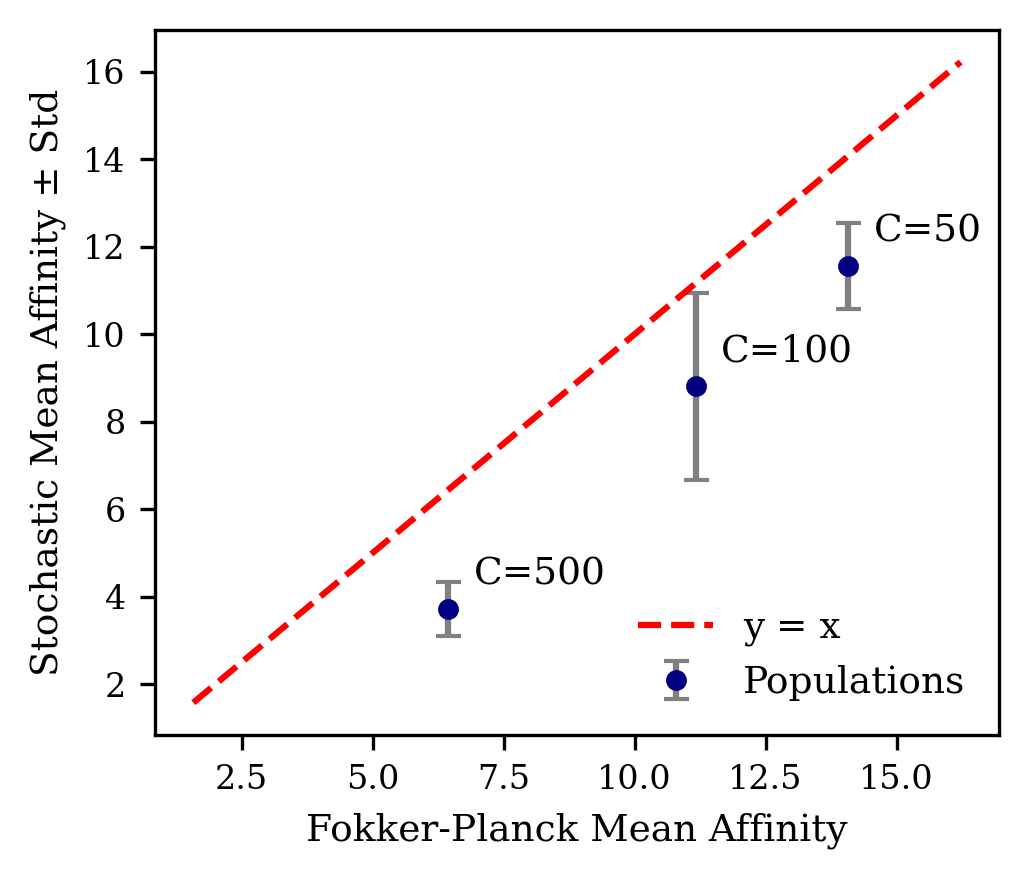

In [ ]:

# ---------------------- Plotting ----------------------
plt.figure(figsize=(3.5, 3), dpi=300)

if valid_c:
    # Scatter plot with y-error bars only (FP on X, Stoch on Y)
    plt.errorbar(
        x=fp_means, y=stoch_means, 
        yerr=stoch_stds, 
        fmt='o', color='navy', ecolor='gray', capsize=3, label='Populations'
    )
    
    # Annotate each point with its concentration
    for i, c in enumerate(valid_c):
        plt.annotate(
            f"C={c}", 
            (fp_means[i], stoch_means[i]), 
            textcoords="offset points", 
            xytext=(6, 6), 
            ha='left', 
            fontsize=9
        )

    # Add reference line y = x to show perfect agreement
    min_val = min(min(stoch_means), min(fp_means)) - max(stoch_stds)
    max_val = max(max(stoch_means), max(fp_means)) + max(stoch_stds)
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1.5, label='y = x')

# If any populations died, list them in a text box on the graph
if dead_c_info:
    # Combine all dead info into one string if there are multiple
    text_str = "\n".join(dead_c_info)
    plt.gca().text(
        0.75, 0.95, text_str, 
        transform=plt.gca().transAxes,
        fontsize=8, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='mistyrose', edgecolor='red', alpha=0.7)
    )

plt.xlabel("Fokker-Planck Mean Affinity")
plt.ylabel("Stochastic Mean Affinity ± Std")

plt.legend(frameon=False, loc='lower right')
plt.tight_layout()

plt.show()

# Surviving proba

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------- Mean Affinity vs FP Comparison ----------------------
# c_array = [1, 3, 5, 7, 9, 11, 13]
c_array = np.logspace(-1, 2, 12)  # 10 values from 1 to 1000 on a log scale

N_SEEDS = 10
survival_mean_arr = []

for c in c_array:
    def C_schedule(r): return np.array([c])
    
    print(f"Simulating for c={c} across {N_SEEDS} seeds...")
    
    c_survied = 0
    
    # Run Simulation for 10 seeds
    for seed in range(N_SEEDS):
        history = simulate_gc_with_ancestry(
            rounds=T,                
            S_mat=S_mat,
            N_init=N_i,
            N_max=N_max,
            C_schedule=C_schedule,   
            mu_M=mu_arr,             
            sigma_M=sigma_arr,       
            mutable_positions=cdr_positions_relative, 
            seed=seed+1              
        )
        
        # Extract the final state from history
        final_frame = history[-1]
        final_pop = final_frame['pop']

        # If population is not dead, calculate and store its mean affinity
        if len(final_pop) > 0:
            c_survied += 1
    survival_mean_arr.append(c_survied / N_SEEDS)

# ---------------------- Plotting ----------------------#save the results to csv
df_survival = pd.DataFrame({
    'c': c_array,
    'survival_rate': survival_mean_arr
})

df_survival.to_csv('survival_rates_log.csv', index=False)



            
    

Simulating for c=0.1 across 10 seeds...
Simulating for c=0.1873817422860384 across 10 seeds...
Simulating for c=0.3511191734215131 across 10 seeds...
Simulating for c=0.6579332246575679 across 10 seeds...
Simulating for c=1.232846739442066 across 10 seeds...
Simulating for c=2.3101297000831593 across 10 seeds...
Simulating for c=4.328761281083057 across 10 seeds...
Simulating for c=8.111308307896868 across 10 seeds...
Simulating for c=15.199110829529332 across 10 seeds...
Simulating for c=28.48035868435799 across 10 seeds...
Simulating for c=53.36699231206307 across 10 seeds...
Simulating for c=100.0 across 10 seeds...


In [ ]:
c_array = np.logspace(-1, 2, 12)  # 10 values from 1 to 1000 on a log scale


In [ ]:
df_survival_fp = pd.read_csv('../multi Ag/survival_rate_fp_log.csv')
df_survival_fp

,c,rho_c,survival_rate
0,0.100000,0.000000e+00,7.577451e-140
1,0.187382,0.000000e+00,5.533853e-105
2,0.351119,0.000000e+00,1.221849e-73
3,0.657933,0.000000e+00,4.388254e-47
4,1.232847,0.000000e+00,3.683466e-26
5,2.310130,0.000000e+00,8.446664e-11
6,4.328761,0.000000e+00,1.000178e+00
7,8.111308,0.000000e+00,1.000175e+00
8,15.199111,0.000000e+00,1.000311e+00
9,28.480359,0.000000e+00,1.000262e+00


Index(['c', 'rho_c', 'survival_rate'], dtype='object')


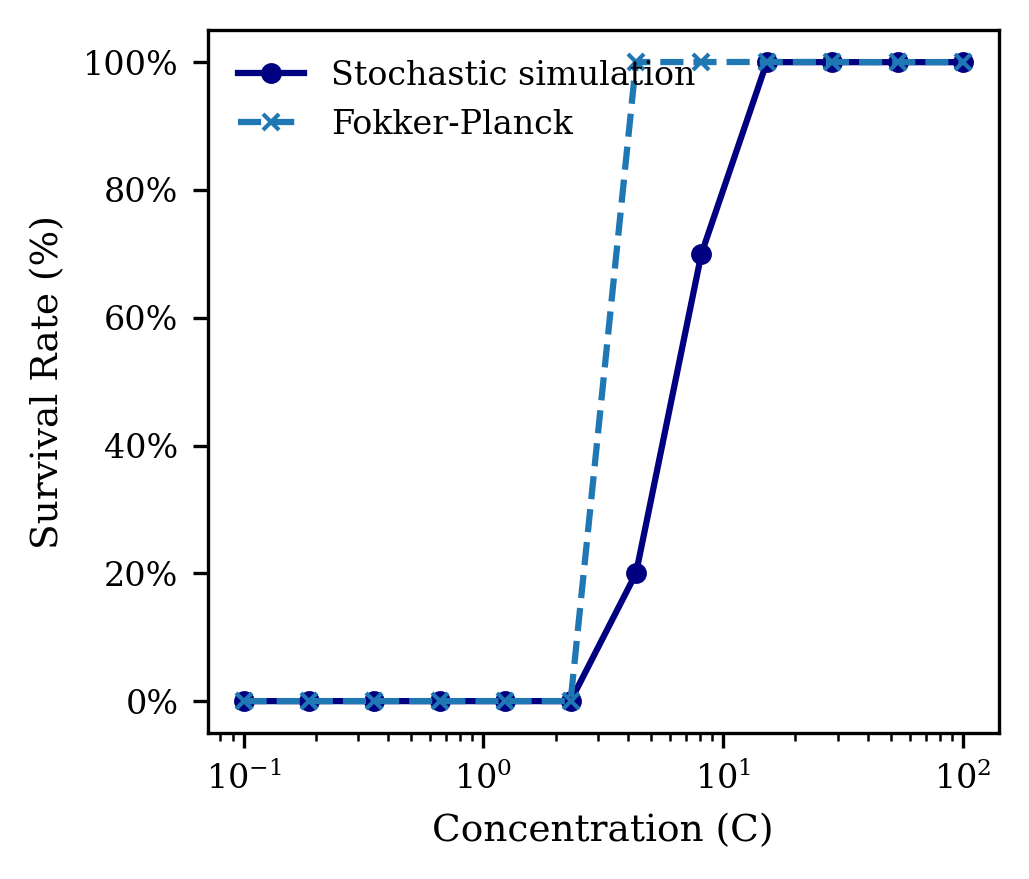

In [ ]:

print(df_survival_fp.columns)
#Index(['c', 'rho_c', 'survival_rate'], dtype='object')


plt.figure(figsize=(3.5, 3), dpi=300)

# Plot your first dataset
plt.plot(c_array, survival_mean_arr, marker='o', color='navy', label='Stochastic simulation')

# Group the Fokker-Planck dataframe by rho_c to plot a line for each parameter set
for rho_c, group in df_survival_fp.groupby('rho_c'):
    if rho_c != 0:
        continue
    # Sorting by 'c' ensures the line connects points left-to-right correctly
    group = group.sort_values(by='c')
    # plt.plot(group['c'], group['survival_rate'], marker='x', linestyle='--', label=rf'FP ($\rho_c={rho_c}$)')
    plt.plot(group['c'], group['survival_rate'], marker='x', linestyle='--', label='Fokker-Planck')


plt.xlabel("Concentration (C)")
plt.ylabel("Survival Rate (%)")
# plt.title("Survival Rate vs Antigen Concentration")
plt.xscale('log')  # Set x-axis to logarithmic scale

# Format the y-axis ticks as percentages (assuming your raw data is in fractions 0.0 to 1.0)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

plt.legend(fontsize=8, frameon=False, loc='upper left')
# plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Optimal protocols

In [ ]:
df_conc=pd.read_csv('../multi Ag/c_star_over_time.csv')
def C_schedule_opti(t):
    # Interpolate the concentration value at time t from the dataframe
    return np.interp(t, df_conc['time'], df_conc['c_star'])
def C_schedule(t):
    return np.array([c])
C_schedule(20)


array([100.])

In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# c=170
# for seed in range(2):
    
#     # Run Simulation
#     print(f"Simulating for c={c}...")
#     # IMPORTANT: Commented out the local C_schedule override so this 
#     # snippet uses the exact same global C_schedule as Snippet 1.
#     # def C_schedule(): return np.array([c])
    
#     # Run Simulation
#     print(f"Simulating for c={c}...")
#     history = simulate_gc_with_ancestry(
#         rounds=T,                # Corrected: Matches Snippet 1 exactly (was T_steps)
#         S_mat=S_mat,
#         N_init=N_i,
#         N_max=N_max,
#         C_schedule=C_schedule_opti,   # Now uses the identical global C_schedule
#         mu_M=mu_arr,             
#         sigma_M=sigma_arr,       
#         mutable_positions=cdr_positions_relative, 
#         seed=seed,                   # Corrected: Matches the first seed run in Snippet 1
#         sigma_init=sigma_i,             # Ensure same initial conditions as Snippet 1
#         mu_init=mu_i

#     )
    
#     # 1. Extract the final state from history
#     final_frame = history[-1]
#     final_pop = final_frame['pop']

#     # 2. Calculate total affinities (sum of h_i) for the final population
#     final_affinities = np.sum(np.nan_to_num(final_pop, nan=0.0), axis=1)
    
#     print(f"Final population size for c={c}: {len(final_affinities)}")
#     print(final_affinities.mean())

    

#     # Load the csv of results from fokker planck
#     fp_filename = f'../multi Ag/rho_epsilon_last_step_c={c}.csv'
#     df_fp = pd.read_csv(fp_filename)
#     eps_fp = df_fp['epsilon']
#     rho_fp = df_fp['rho_epsilon']

#     # 3. Create the Histogram Plot
#     plt.figure(figsize=(3, 2.6), dpi=300)  # Maintaining your PRL-style sizing

#     # Plot histogram of stochastic simulation and CAPTURE the bins
#     counts, bins, patches = plt.hist(
#         final_affinities, bins=30, color='skyblue', edgecolor='navy', 
#         alpha=0.7, label='Stochastic'
#     )

#     # Calculate the bin width of the stochastic histogram
#     bin_width = bins[1] - bins[0]
    
#     # Calculate the grid spacing of the Fokker-Planck continuous data
#     deps_fp = eps_fp.iloc[1] - eps_fp.iloc[0]
    
#     # Scale rho_fp smoothly to match the histogram 'Count' scale.
#     scaled_rho_fp = rho_fp * (bin_width / deps_fp)

#     # Plot Fokker Planck smoothly using its native resolution
#     plt.plot(eps_fp, scaled_rho_fp, color='darkorange', label='Fokker-Planck', linestyle='--')

#     # 4. Formatting
#     plt.xlabel(r"Affinity $\epsilon$")
#     plt.ylabel("Count")

#     plt.legend(frameon=False, fontsize='small')
#     plt.tight_layout()
#     plt.ylim(0, 800)  # Adjust y-limit for better visualization

#     plt.show()

In [ ]:
import numpy as np

def get_schedule_from_inj(C_opt, t_opt, tau):
    C_opt = np.array(C_opt)
    t_opt = np.array(t_opt)
    
    def get_c(t):
        # Handle both scalar and array inputs for t
        t_is_scalar = np.isscalar(t)
        t_arr = np.atleast_1d(t)
        
        C_total = np.zeros_like(t_arr, dtype=float)
        
        # Add the decaying concentration for each injection that has already occurred
        for c_val, t_val in zip(C_opt, t_opt):
            mask = t_arr >= t_val
            C_total[mask] += c_val * np.exp(-(t_arr[mask] - t_val) / tau)
            
        # Guarantee the output is a numpy array to match your simulation's expectations
        if t_is_scalar:
            return np.array([C_total[0]])
        else:
            return C_total
        
    return get_c

# --- Example usage ---
function = get_schedule_from_inj(
    C_opt=[32,32,32],
    t_opt=[0., 56, 112],
    tau=20.0
)
df_created_schedule= pd.DataFrame({
    'time': np.linspace(0, 140, 28001),
    'C': function(np.linspace(0, 140, 28001))
})

def C_schedule_Ninj3id(t):
    return np.array([np.interp(t, df_created_schedule['time'], df_created_schedule['C'])])

df_vacc = pd.read_csv("../multi Ag/optimized_vaccine_concentration.csv")
df_vacc





,time,C_vaccine_Ninj3,C_vaccine_Ninj2,C_vaccine_Ninj1
0,0.000,30.344429,45.620182,792.340450
1,0.005,37.765300,56.776806,986.110960
2,0.010,44.342247,66.664670,1157.845300
3,0.015,49.577408,74.535280,1294.543600
4,0.020,53.398273,80.279610,1394.312300
...,...,...,...,...
27996,139.980,2.218019,1.976743,1.446488
27997,139.985,2.217464,1.976248,1.446126
27998,139.990,2.216909,1.975754,1.445764
27999,139.995,2.216356,1.975261,1.445404


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the optimized schedule data
df_conc = pd.read_csv('../multi Ag/c_star_over_time.csv')

# Define the dynamic schedule function
def C_schedule_opti(t):
    # Wrapped in np.array to match the expected format of constant schedules
    return np.array([np.interp(t, df_conc['time'], df_conc['c_star'])])



df_vacc = pd.read_csv("../multi Ag/optimized_vaccine_concentration.csv")
def C_schedule_Ninj3(t):
    return np.array([np.interp(t, df_vacc['time'], df_vacc['C_vaccine_Ninj3'])])

def C_schedule_Ninj2(t):
    return np.array([np.interp(t, df_vacc['time'], df_vacc['C_vaccine_Ninj2'])])

def C_schedule_Ninj1(t):
    return np.array([np.interp(t, df_vacc['time'], df_vacc['C_vaccine_Ninj1'])])


# Organize all schedules to test in a dictionary
# Using lambda functions with default arguments ensures each constant gets bound correctly
schedules = {
    'Opti': C_schedule_opti,
    r'$N_{inj}=3$': C_schedule_Ninj3,
    r'$N_{inj}=2$': C_schedule_Ninj2,
    r'$N_{inj}=1$': C_schedule_Ninj1,
    r'$N_{inj}=3$ id': C_schedule_Ninj3id,
    'C=5': lambda t, val=5: np.array([val]),
    'C=10': lambda t, val=10: np.array([val]),
    'C=20': lambda t, val=20: np.array([val]),


}

# Dictionary to hold the final mean affinities for each schedule across the seeds
results_mean_aff = {name: [] for name in schedules.keys()}

for sched_name, sched_func in schedules.items():
    print(f"--- Running simulations for schedule: {sched_name} ---")
    
    for seed in range(10):
        print(f"Simulating seed {seed}...")
        
        history = simulate_gc_with_ancestry(
            rounds=T,                
            S_mat=S_mat,
            N_init=N_i,
            N_max=N_max,
            C_schedule=sched_func,   # Passes the current schedule function
            mu_M=mu_arr,             
            sigma_M=sigma_arr,       
            mutable_positions=cdr_positions_relative, 
            seed=seed,                   
            sigma_init=sigma_i,             
            mu_init=mu_i
        )
        
        # Extract the final state from history where population > 1250
        target_frame = None
        i=0
        for frame in reversed(history):
            if len(frame['pop']) > 1250:
                target_frame = frame
                break
            i-=1
        print('frame=', i)
                
        # Fallback in case the population never reaches 1250 for this seed
        if target_frame is None:
            print(f"  Warning: Population never exceeded 1250 for seed {seed}. Defaulting to the last frame.")
            target_frame = history[-1]

        final_pop = target_frame['pop']

        # Calculate total affinities (sum of h_i) for the target population
        final_affinities = np.sum(np.nan_to_num(final_pop, nan=0.0), axis=1)
        mean_affinity = final_affinities.mean()
        
        # Store the result
        results_mean_aff[sched_name].append(mean_affinity)



--- Running simulations for schedule: Opti ---
Simulating seed 0...
frame= 0
Simulating seed 1...
frame= -68
Simulating seed 2...
frame= -8
Simulating seed 3...
frame= 0
Simulating seed 4...
frame= 0
Simulating seed 5...
frame= -25
Simulating seed 6...
frame= 0
Simulating seed 7...
frame= 0
Simulating seed 8...
frame= 0
Simulating seed 9...
frame= 0
--- Running simulations for schedule: $N_{inj}=3$ ---
Simulating seed 0...
frame= 0
Simulating seed 1...
frame= 0
Simulating seed 2...
frame= 0
Simulating seed 3...
frame= -1
Simulating seed 4...
frame= 0
Simulating seed 5...
frame= 0
Simulating seed 6...
frame= -5
Simulating seed 7...
frame= 0
Simulating seed 8...
frame= 0
Simulating seed 9...
frame= 0
--- Running simulations for schedule: $N_{inj}=2$ ---
Simulating seed 0...
frame= -6
Simulating seed 1...
frame= 0
Simulating seed 2...
frame= 0
Simulating seed 3...
frame= -5
Simulating seed 4...
frame= 0
Simulating seed 5...
frame= 0
Simulating seed 6...
frame= 0
Simulating seed 7...
frame

C:\Users\maria\AppData\Local\Temp\ipykernel_3704\1014477827.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(data_to_plot, labels=labels, patch_artist=True)


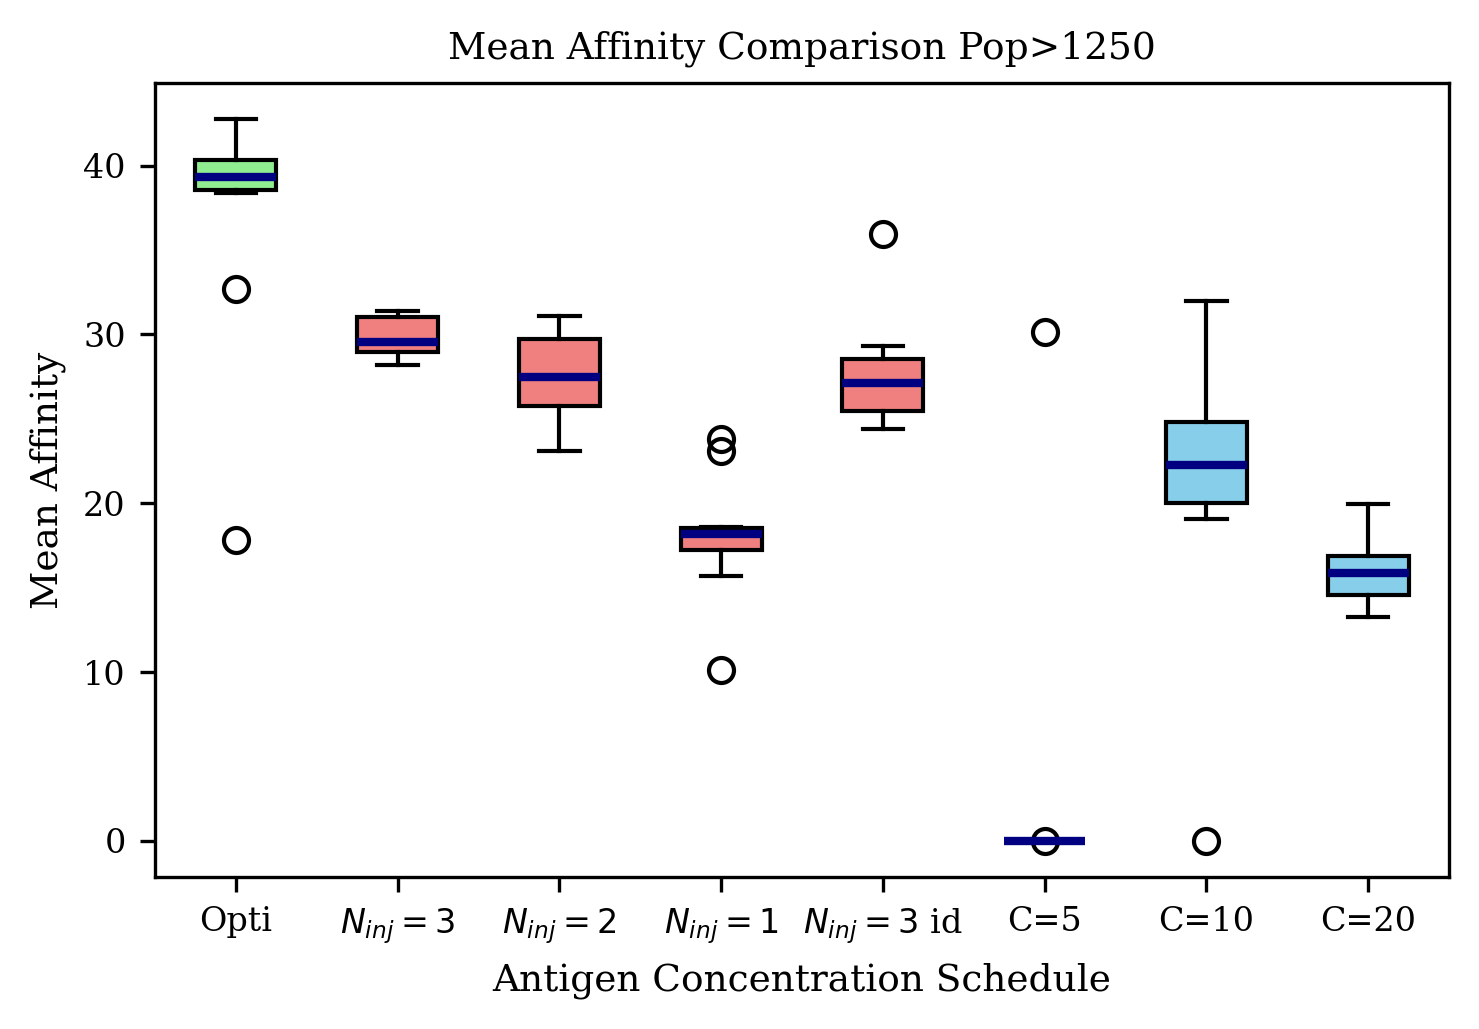

In [ ]:
# --- Create the Candle Plot (Boxplot) ---
plt.figure(figsize=(5, 3.5), dpi=300)

# Extract data arrays and corresponding labels in the correct order
labels = list(results_mean_aff.keys())
data_to_plot = [results_mean_aff[label] for label in labels]

# Create the boxplot
box = plt.boxplot(data_to_plot, labels=labels, patch_artist=True)

# Formatting the box colors for visual distinction
for patch, label in zip(box['boxes'], labels):
    if label == 'Opti':
        patch.set_facecolor('lightgreen')
    elif 'inj' in label:
        patch.set_facecolor('lightcoral')
    else:
        patch.set_facecolor('skyblue')
        
# Set styling
plt.setp(box['medians'], color='navy', linewidth=2)

plt.xlabel("Antigen Concentration Schedule")
plt.ylabel("Mean Affinity")
plt.title("Mean Affinity Comparison Pop>1250")
# plt.grid(True, linestyle=':', alpha=0.6, axis='y')
plt.tight_layout()

plt.show()

In [ ]:

# Dictionary to hold the final mean affinities for each schedule across the seeds
results_mean_aff = {name: [] for name in schedules.keys()}

for sched_name, sched_func in schedules.items():
    print(f"--- Running simulations for schedule: {sched_name} ---")
    
    for seed in range(10):
        print(f"Simulating seed {seed}...")
        
        history = simulate_gc_with_ancestry(
            rounds=T,                
            S_mat=S_mat,
            N_init=N_i,
            N_max=N_max,
            C_schedule=sched_func,   # Passes the current schedule function
            mu_M=mu_arr,             
            sigma_M=sigma_arr,       
            mutable_positions=cdr_positions_relative, 
            seed=seed,                   
            sigma_init=sigma_i,             
            mu_init=mu_i
        )
        
     
        target_frame =  history[-1]
        if len(frame['pop']) <1:
            results_mean_aff[sched_name].append(0)
            continue
                
        # Fallback in case the population never reaches 1250 for this seed
 

        final_pop = target_frame['pop']

        # Calculate total affinities (sum of h_i) for the target population
        final_affinities = np.sum(np.nan_to_num(final_pop, nan=0.0), axis=1)
        mean_affinity = final_affinities.mean()
        #check not nan
        if np.isnan(mean_affinity):
            print(f"  Warning: Mean affinity is NaN for seed {seed}. Defaulting to 0.")
            mean_affinity = 0.0
        
        # Store the result
        results_mean_aff[sched_name].append(mean_affinity)



--- Running simulations for schedule: Opti ---
Simulating seed 0...
Simulating seed 1...
Simulating seed 2...
Simulating seed 3...
Simulating seed 4...
Simulating seed 5...
Simulating seed 6...
Simulating seed 7...
Simulating seed 8...
Simulating seed 9...
--- Running simulations for schedule: $N_{inj}=3$ ---
Simulating seed 0...
Simulating seed 1...
Simulating seed 2...
Simulating seed 3...
Simulating seed 4...
Simulating seed 5...
Simulating seed 6...
Simulating seed 7...
Simulating seed 8...
Simulating seed 9...
--- Running simulations for schedule: $N_{inj}=2$ ---
Simulating seed 0...
Simulating seed 1...
Simulating seed 2...
Simulating seed 3...
Simulating seed 4...
Simulating seed 5...
Simulating seed 6...
Simulating seed 7...
Simulating seed 8...
Simulating seed 9...
--- Running simulations for schedule: $N_{inj}=1$ ---
Simulating seed 0...
Simulating seed 1...
Simulating seed 2...
Simulating seed 3...
Simulating seed 4...
Simulating seed 5...
Simulating seed 6...
Simulating see

C:\Users\maria\AppData\Local\Temp\ipykernel_3704\895126819.py:37: RuntimeWarning: Mean of empty slice.
  mean_affinity = final_affinities.mean()
c:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Simulating seed 5...
Simulating seed 6...
Simulating seed 7...
Simulating seed 8...
Simulating seed 9...
--- Running simulations for schedule: C=10 ---
Simulating seed 0...
Simulating seed 1...
Simulating seed 2...
Simulating seed 3...
Simulating seed 4...
Simulating seed 5...
Simulating seed 6...
Simulating seed 7...
Simulating seed 8...
Simulating seed 9...
--- Running simulations for schedule: C=20 ---
Simulating seed 0...
Simulating seed 1...
Simulating seed 2...
Simulating seed 3...
Simulating seed 4...
Simulating seed 5...
Simulating seed 6...
Simulating seed 7...
Simulating seed 8...
Simulating seed 9...


C:\Users\maria\AppData\Local\Temp\ipykernel_3704\1130319413.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(data_to_plot, labels=labels, patch_artist=True)


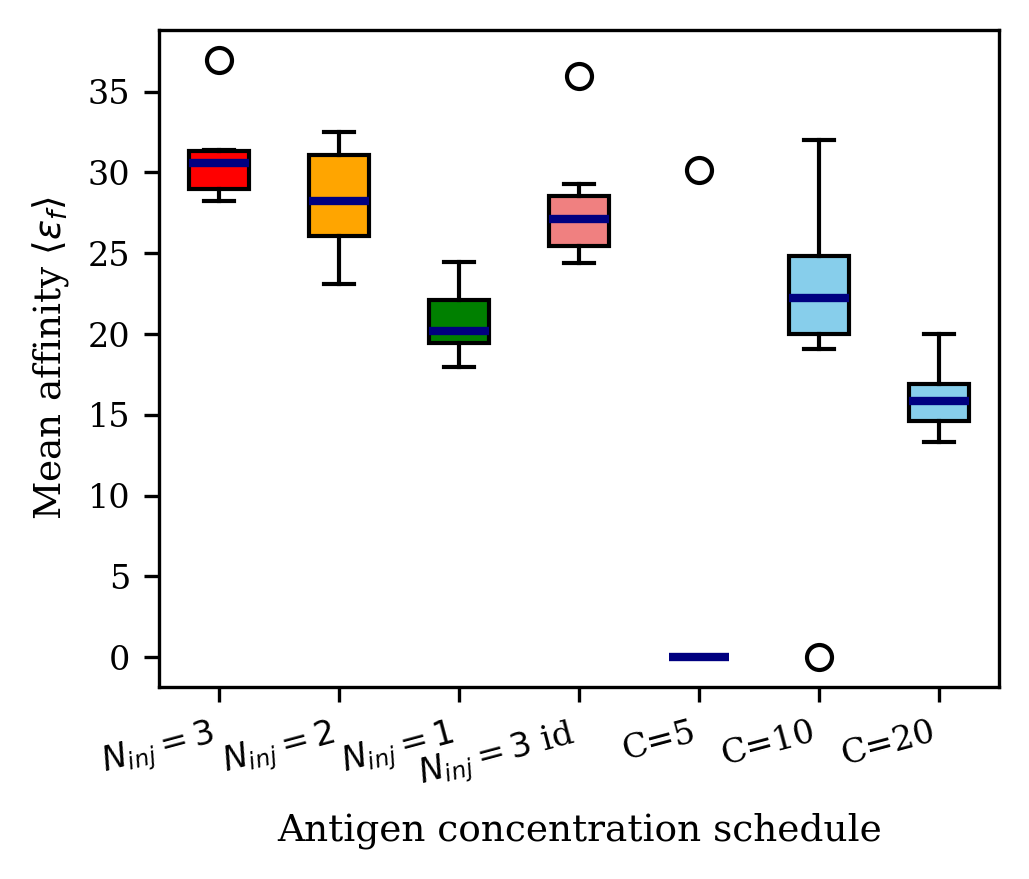

In [ ]:
# --- Create the Candle Plot (Boxplot) ---
plt.figure(figsize=(3.5, 3), dpi=300)

# Extract data arrays and corresponding labels in the correct order
labels = list(results_mean_aff.keys())
data_to_plot = [results_mean_aff[label] for label in labels]
#remove opti from the plot
labels = [label for label in labels if label != 'Opti']
data_to_plot = [results_mean_aff[label] for label in labels if label != 'Opti']

# Create the boxplot
box = plt.boxplot(data_to_plot, labels=labels, patch_artist=True)

# Formatting the box colors for visual distinction
for patch, label in zip(box['boxes'], labels):
    if label == 'Opti':
        patch.set_facecolor('lightgreen')
    elif label == r'$N_{inj}=3$':
        patch.set_facecolor('red')
    elif label == r'$N_{inj}=2$':
        patch.set_facecolor('orange')
    elif label == r'$N_{inj}=1$':
        patch.set_facecolor('green')
    elif 'inj' in label:
        patch.set_facecolor('lightcoral')
    else:
        patch.set_facecolor('skyblue')
        
# Set styling
plt.setp(box['medians'], color='navy', linewidth=2)

plt.xlabel("Antigen concentration schedule")
plt.ylabel(r'Mean affinity $\langle \epsilon_f \rangle$')
#size of x labels
plt.xticks(rotation=15, ha='right', fontsize=8)
# plt.title("Mean Affinity Comparison (last pop)")
# plt.grid(True, linestyle=':', alpha=0.6, axis='y')
plt.tight_layout()

plt.show()